# California Real Estate — Exploratory Data Analysis

**Data Source:** CRMLS (California Regional Multiple Listing Service) via CoreLogic Trestle API  
**Coverage:** January 2024 — March 2026 (27 months)  
**Datasets:**
- `priceratio.csv` — Closed residential transactions with derived market metrics
- `newlistings.csv` — New residential listings

**Objective:** Identify meaningful patterns and relationships in the California housing market to inform the construction of market analysis and competitive analysis Tableau dashboards.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sys
import os

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Add project root to path so we can import our modules
sys.path.insert(0, os.path.abspath('..'))

from data_cleaning.helpers.duplicates import drop_duplicate_columns
from data_cleaning.helpers.dates import parse_sold_dates, parse_listing_dates
from data_cleaning.helpers.missing import missing_value_report
from data_cleaning.helpers.outliers import flag_outliers, filter_outliers, compare_before_after
from data_cleaning.helpers.mortgage_rates import load_mortgage_rates, merge_mortgage_rates
from data_cleaning.helpers.dates import parse_all_date_fields, add_date_consistency_flags
from data_cleaning.helpers.validation import flag_invalid_numerics
from data_cleaning.helpers.geographic import flag_invalid_coordinates

from feature_engineering.helpers.engineer_features import (
    add_market_condition, add_price_reduction_flags,
    add_dom_buckets, add_price_tiers
)
from feature_engineering.add_new_features import engineer_sold_features, engineer_listing_features

from exploratory_analysis.helpers.visualize import (
    plot_missing_values, plot_boxplots, plot_sold_distributions,
    plot_listing_distributions, plot_monthly_kpi_trends, plot_yoy_comparison,
    plot_supply_vs_demand, plot_top_counties, plot_top_cities,
    plot_subtype_comparison, plot_price_vs_size, plot_dom_bucket_analysis,
    plot_price_reductions, plot_top_offices, plot_top_agents,
    plot_correlation_heatmap, plot_close_vs_list, plot_price_tiers,
    plot_new_construction
)
from exploratory_analysis.helpers.stats import (
    monthly_sold_summary, monthly_listing_summary, geographic_summary,
    dom_bucket_summary, competitive_summary, price_tier_summary,
    percentile_summary, segment_summary, market_summary
)

---
## 1. Load Data


In [2]:
sold = pd.read_csv('../data/priceratio.csv', encoding='ISO-8859-1')
listings = pd.read_csv('../data/newlistings.csv', encoding='ISO-8859-1')

print(f"Sold transactions: {sold.shape[0]:,} rows x {sold.shape[1]} columns")
print(f"New listings:      {listings.shape[0]:,} rows x {listings.shape[1]} columns")

Sold transactions: 414,374 rows x 49 columns
New listings:      566,231 rows x 84 columns


### Property Type Breakdown

Document the unique property types in each dataset before filtering.


In [3]:
# Unique property types in sold data
if 'PropertyType' in sold.columns:
    print('=== Sold — Property Types ===')
    print(sold['PropertyType'].value_counts())
    print(f'\nTotal unique: {sold["PropertyType"].nunique()}')
else:
    print('PropertyType column not found — dataset is pre-filtered to Residential')

if 'PropertyType' in listings.columns:
    print('\n=== Listings — Property Types ===')
    print(listings['PropertyType'].value_counts())
    print(f'\nTotal unique: {listings["PropertyType"].nunique()}')
else:
    print('PropertyType column not found — dataset is pre-filtered to Residential')


=== Sold — Property Types ===
PropertyType
Residential    414374
Name: count, dtype: int64

Total unique: 1

=== Listings — Property Types ===
PropertyType
Residential    566231
Name: count, dtype: int64

Total unique: 1


---
## 2. Data Overview

Inspect schema, data types, and summary statistics for both datasets.


In [4]:
print("=== Sold Transactions (priceratio.csv) ===")
print(f"Columns: {sold.columns.tolist()}")
sold.info()

=== Sold Transactions (priceratio.csv) ===
Columns: ['OriginalListPrice', 'ListingKey', 'CloseDate', 'ClosePrice', 'Latitude', 'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea', 'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName', 'CoListOfficeName', 'ListAgentFullName', 'BuyerAgentMlsId', 'BuyerAgentFirstName', 'BuyerAgentLastName', 'FireplacesTotal', 'CountyOrParish', 'AttachedGarageYN', 'ParkingTotal', 'PropertySubType', 'LotSizeAcres', 'SubdivisionName', 'YearBuilt', 'ListingId', 'BathroomsTotalInteger', 'City', 'BuildingAreaTotal', 'BedroomsTotal', 'ContractStatusChangeDate', 'PurchaseContractDate', 'ListingContractDate', 'StateOrProvince', 'CoveredSpaces', 'Stories', 'Levels', 'LotSizeDimensions', 'LotSizeArea', 'MainLevelBedrooms', 'NewConstructionYN', 'GarageSpaces', 'PostalCode', 'LotSizeSquareFeet', 'OriginatingSystemName', 'OriginatingSystemSubName', 'priceratio', 'pricesqft']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414374 entries, 0 to 4143

In [5]:
sold.describe()


,OriginalListPrice,ListingKey,ClosePrice,Latitude,Longitude,LivingArea,ListPrice,DaysOnMarket,FireplacesTotal,ParkingTotal,LotSizeAcres,YearBuilt,BathroomsTotalInteger,BuildingAreaTotal,BedroomsTotal,CoveredSpaces,Stories,LotSizeArea,MainLevelBedrooms,GarageSpaces,LotSizeSquareFeet,priceratio,pricesqft
count,413612.00,414374.00,414372.00,410196.00,410196.00,414140.00,414374.00,383840.00,0.00,413944.00,381801.00,414000.00,414305.00,29038.00,414363.00,0.00,350534.00,382332.00,240379.00,396589.00,382203.00,374801.00,414138.00
mean,1225273.41,1098148681.79,1189853.51,34.70,-118.63,1903.72,1140410.39,27.12,NaN,9.06,66.26,1978.58,2.53,2122.83,3.20,NaN,1.36,39137.75,2.06,1.86,328633.58,0.99,inf
std,6707451.56,31326976.89,6123050.16,1.74,2.98,26465.98,1359272.08,27.69,NaN,4031.45,15992.27,26.28,1.13,1698.55,1.07,NaN,0.48,2202534.77,7.10,3.67,16049759.68,0.05,NaN
min,0.00,421678487.00,0.00,-117.47,-177.65,0.00,525.00,-65.00,NaN,-143.00,0.00,1776.00,0.00,0.00,0.00,NaN,1.00,0.00,0.00,0.00,0.00,0.83,0.00
25%,585000.00,1075491358.25,575000.00,33.74,-119.15,1248.00,576191.00,7.00,NaN,2.00,0.12,1960.00,2.00,1272.00,3.00,NaN,1.00,5000.00,1.00,2.00,5227.00,0.96,368.48
50%,825000.00,1097311085.50,822944.00,34.05,-118.03,1642.00,815000.00,16.00,NaN,2.00,0.17,1979.00,2.00,1717.00,3.00,NaN,1.00,7014.50,2.00,2.00,7245.00,1.00,537.56
75%,1299000.00,1118694318.75,1300000.00,34.70,-117.27,2219.00,1295000.00,39.00,NaN,3.00,0.27,1999.00,3.00,2462.00,4.00,NaN,2.00,10890.00,3.00,2.00,11865.50,1.02,732.60
max,1390000000.00,1159293092.00,989500000.00,56.13,329.00,17021321.00,137500000.00,168.00,NaN,2593669.00,7810698.36,2026.00,175.00,123764.00,45.00,NaN,2.00,918742280.00,3333.00,600.00,2208317760.00,1.15,inf


In [6]:
print("=== New Listings (newlistings.csv) ===")
print(f"Columns: {listings.columns.tolist()}")
listings.info()

=== New Listings (newlistings.csv) ===
Columns: ['OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate', 'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude', 'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea', 'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName', 'CoListOfficeName', 'ListAgentFullName', 'CoListAgentFirstName', 'CoListAgentLastName', 'BuyerAgentMlsId', 'BuyerAgentFirstName', 'BuyerAgentLastName', 'FireplacesTotal', 'AssociationFeeFrequency', 'AboveGradeFinishedArea', 'ListingKeyNumeric', 'MLSAreaMajor', 'TaxAnnualAmount', 'CountyOrParish', 'PropertyType.1', 'MlsStatus', 'ElementarySchool', 'ListAgentFirstName.1', 'AttachedGarageYN', 'ParkingTotal', 'BuilderName', 'PropertySubType', 'LotSizeAcres', 'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt', 'DaysOnMarket.1', 'BuyerAgencyCompensationType', 'StreetNumberNumeric', 'LivingArea.1', 'ListingId', 'BathroomsTotalInteger', 'City', 'BuyerAgencyCompensation', 'TaxYear', 'Buildi

In [7]:
listings.describe()

,OriginalListPrice,ListingKey,ClosePrice,Latitude,Longitude,LivingArea,ListPrice,DaysOnMarket,FireplacesTotal,AboveGradeFinishedArea,ListingKeyNumeric,TaxAnnualAmount,ParkingTotal,LotSizeAcres,YearBuilt,DaysOnMarket.1,StreetNumberNumeric,LivingArea.1,BathroomsTotalInteger,BuyerAgencyCompensation,TaxYear,BuildingAreaTotal,BedroomsTotal,Longitude.1,ElementarySchoolDistrict,BelowGradeFinishedArea,BusinessType,Latitude.1,ListPrice.1,CoveredSpaces,Stories,LotSizeArea,MainLevelBedrooms,GarageSpaces,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict
count,565422.00,566231.00,147775.00,485787.00,485787.00,565655.00,566231.00,566231.00,0.00,0.00,566231.00,0.00,566211.00,519691.00,565260.00,566231.00,565244.00,565655.00,566174.00,78993.00,0.00,50405.00,566079.00,485787.00,0.00,3208.00,0.00,485787.00,566231.00,0.00,466946.00,520573.00,307413.00,534744.00,429892.00,520395.00,0.00
mean,1400336.71,1107241556.86,1203249.12,34.62,-118.48,1980.47,1317075.69,19.09,NaN,NaN,1107241556.86,NaN,7.40,62.80,1979.64,19.09,11428.96,1980.47,2.63,189.11,NaN,2448.51,3.23,-118.48,NaN,85.64,NaN,34.62,1317075.69,NaN,1.37,47610.96,2.04,1.85,271.71,413321.25,NaN
std,7293537.14,31235707.75,4266016.24,1.99,3.52,22840.11,2413696.85,26.42,NaN,NaN,31235707.75,NaN,3447.03,11853.27,27.01,26.42,275343.81,22840.11,3.19,2340.72,NaN,2275.48,1.19,3.52,NaN,355.64,NaN,1.99,2413696.85,NaN,0.48,2241505.60,6.30,3.87,2319.29,20728653.78,NaN
min,0.00,1018357250.00,525.00,-117.47,-159.48,0.00,100.00,-58.00,NaN,NaN,1018357250.00,NaN,-143.00,0.00,1776.00,-58.00,0.00,0.00,0.00,0.00,NaN,0.00,0.00,-159.48,NaN,0.00,NaN,-117.47,100.00,NaN,1.00,0.00,0.00,0.00,0.00,0.00,NaN
25%,585000.00,1077680347.50,600000.00,33.74,-118.74,1248.00,580000.00,5.00,NaN,NaN,1077680347.50,NaN,2.00,0.12,1961.00,5.00,972.00,1248.00,2.00,2.00,NaN,1305.00,2.00,-118.74,NaN,0.00,NaN,33.74,580000.00,NaN,1.00,5000.00,1.00,1.00,0.00,5227.00,NaN
50%,849000.00,1107754276.00,855000.00,34.06,-118.03,1670.00,848000.00,11.00,NaN,NaN,1107754276.00,NaN,2.00,0.17,1980.00,11.00,3261.00,1670.00,2.00,2.50,NaN,1826.00,3.00,-118.03,NaN,0.00,NaN,34.06,848000.00,NaN,1.00,7192.00,2.00,2.00,126.00,7405.00,NaN
75%,1395000.00,1135758764.00,1350000.00,34.49,-117.24,2301.00,1380000.00,22.00,NaN,NaN,1135758764.00,NaN,3.00,0.31,2001.00,22.00,12034.25,2301.00,3.00,2.50,NaN,2799.00,4.00,-117.24,NaN,0.00,NaN,34.49,1380000.00,NaN,2.00,12075.00,3.00,2.00,400.00,13639.00,NaN
max,1390000000.00,1159445965.00,820000000.00,737.00,329.00,17021321.00,400000000.00,731.00,NaN,NaN,1159445965.00,NaN,2593669.00,4187292.00,2028.00,731.00,79547958.00,17021321.00,2208.00,200000.00,NaN,123764.00,94.00,329.00,NaN,5000.00,NaN,737.00,400000000.00,NaN,2.00,918742280.00,3333.00,600.00,968348.00,7638115320.00,NaN


---
## 3. Data Cleaning

### 3a. Handle Duplicate Columns in Listings

The  file contains duplicate column names from the API extraction. These are redundant and should be dropped before analysis.


In [8]:
listings = drop_duplicate_columns(listings)

Duplicate columns to drop (11):
['PropertyType.1', 'ListAgentFirstName.1', 'DaysOnMarket.1', 'LivingArea.1', 'Longitude.1', 'Latitude.1', 'ListPrice.1', 'ListAgentLastName.1', 'CloseDate.1', 'BuyerOfficeName.1', 'UnparsedAddress.1']

Shape after dropping duplicates: (566231, 73)


### 3b. Parse Date Columns and Create Time Features

In [9]:
sold = parse_sold_dates(sold)
listings = parse_listing_dates(listings)

Sold date range: 2024-01-01 to 2026-04-30
Listings date range: 2024-01-01 to 2026-04-30


### 3c. Mortgage Rate Enrichment

Merge the 30-year fixed mortgage rate (FRED MORTGAGE30US) onto both datasets.
Weekly rates are resampled to monthly averages and joined on a year-month key.


In [10]:
mortgage_monthly = load_mortgage_rates('../data/MORTGAGE30US.csv')

sold = merge_mortgage_rates(sold, mortgage_monthly, date_col='CloseDate')
listings = merge_mortgage_rates(listings, mortgage_monthly, date_col='ListingContractDate')

# Preview the merge
print(sold[['CloseDate', 'year_month', 'ClosePrice', 'rate_30yr_fixed']].head())


Mortgage rates loaded: 661 months (1971-04 to 2026-04)
Merged on CloseDate: 0 rows with null rate (0.00%)
Merged on ListingContractDate: 0 rows with null rate (0.00%)
   CloseDate year_month  ClosePrice  rate_30yr_fixed
0 2024-01-26    2024-01   240000.00             6.64
1 2024-01-05    2024-01   815000.00             6.64
2 2024-01-05    2024-01   810000.00             6.64
3 2024-01-02    2024-01  2100000.00             6.64
4 2024-01-22    2024-01  1950000.00             6.64


In [11]:
# Save enriched datasets with mortgage rates
sold.to_csv('../data/mortgage_enriched/sold_with_rates.csv', index=False)
listings.to_csv('../data/mortgage_enriched/listings_with_rates.csv', index=False)

print(f'Saved sold_with_rates.csv: {sold.shape[0]:,} rows')
print(f'Saved listings_with_rates.csv: {listings.shape[0]:,} rows')


Saved sold_with_rates.csv: 414,374 rows
Saved listings_with_rates.csv: 566,231 rows


### 3d. Data Validation — Weeks 4-5

Apply validation checks, date consistency flags, and geographic quality flags.
These steps prepare the dataset for reliable analytics.


### Parse All Date Fields

Convert CloseDate, PurchaseContractDate, ListingContractDate, and ContractStatusChangeDate to datetime.


In [12]:
sold = parse_all_date_fields(sold)
listings = parse_all_date_fields(listings)


Parsed 4 date columns: ['CloseDate', 'PurchaseContractDate', 'ListingContractDate', 'ContractStatusChangeDate']
Parsed 4 date columns: ['CloseDate', 'PurchaseContractDate', 'ListingContractDate', 'ContractStatusChangeDate']


### Date Consistency Checks

Flag records where dates violate logical ordering: ListingContractDate should precede PurchaseContractDate, which should precede CloseDate.


In [13]:
sold = add_date_consistency_flags(sold)


=== Date Consistency Flags ===
  listing_after_close_flag: 61 records (0.01%)
  purchase_after_close_flag: 239 records (0.06%)
  negative_timeline_flag: 298 records (0.07%)


### Invalid Numeric Value Flags

Flag records with ClosePrice <= 0, LivingArea <= 0, DaysOnMarket < 0, or negative bedrooms/bathrooms.


In [14]:
sold = flag_invalid_numerics(sold)
listings = flag_invalid_numerics(listings)


=== Invalid Numeric Value Flags ===
  invalid_close_price: 1 records (0.00%)
  invalid_living_area: 150 records (0.04%)
  invalid_dom: 39 records (0.01%)
  invalid_bedrooms: 0 records (0.00%)
  invalid_bathrooms: 0 records (0.00%)
  any_invalid_flag: 190 records (0.05%)
=== Invalid Numeric Value Flags ===
  invalid_close_price: 0 records (0.00%)
  invalid_living_area: 377 records (0.07%)
  invalid_dom: 29 records (0.01%)
  invalid_bedrooms: 0 records (0.00%)
  invalid_bathrooms: 0 records (0.00%)
  any_invalid_flag: 406 records (0.07%)


### Geographic Data Quality

Flag records with missing/zero coordinates, positive longitude (should be negative in CA), and out-of-state coordinates.


In [15]:
sold = flag_invalid_coordinates(sold)
listings = flag_invalid_coordinates(listings)


=== Geographic Data Quality Flags ===
  missing_coords_flag: 4,178 records (1.01%)
  zero_coords_flag: 27 records (0.01%)
  positive_lon_flag: 31 records (0.01%)
  out_of_state_flag: 64 records (0.02%)
  any_geo_flag: 4,269 records (1.03%)
=== Geographic Data Quality Flags ===
  missing_coords_flag: 80,444 records (14.21%)
  zero_coords_flag: 65 records (0.01%)
  positive_lon_flag: 78 records (0.01%)
  out_of_state_flag: 254 records (0.04%)
  any_geo_flag: 80,763 records (14.26%)


### Cleaning Summary & Save

Report before/after row counts and save the cleaned dataset.


In [16]:
# Before/after summary
print('=== Cleaning Summary — Sold ===')
print(f'Total rows: {len(sold):,}')
if 'negative_timeline_flag' in sold.columns:
    print(f'Date inconsistencies: {sold["negative_timeline_flag"].sum():,}')
if 'any_invalid_flag' in sold.columns:
    print(f'Invalid numeric values: {sold["any_invalid_flag"].sum():,}')
if 'any_geo_flag' in sold.columns:
    print(f'Geographic issues: {sold["any_geo_flag"].sum():,}')

print('\n=== Cleaning Summary — Listings ===')
print(f'Total rows: {len(listings):,}')
if 'any_invalid_flag' in listings.columns:
    print(f'Invalid numeric values: {listings["any_invalid_flag"].sum():,}')
if 'any_geo_flag' in listings.columns:
    print(f'Geographic issues: {listings["any_geo_flag"].sum():,}')

# Save cleaned datasets
sold.to_csv('../data/cleaned_sold.csv', index=False)
listings.to_csv('../data/cleaned_lis' \
'tings.csv', index=False)
print(f'\nSaved cleaned_sold.csv: {len(sold):,} rows')
print(f'Saved cleaned_listings.csv: {len(listings):,} rows')


=== Cleaning Summary — Sold ===
Total rows: 414,374
Date inconsistencies: 298
Invalid numeric values: 190
Geographic issues: 4,269

=== Cleaning Summary — Listings ===
Total rows: 566,231
Invalid numeric values: 406
Geographic issues: 80,763

Saved cleaned_sold.csv: 414,374 rows
Saved cleaned_listings.csv: 566,231 rows


### 3e. Missing Data Analysis

In [17]:
sold_missing = missing_value_report(sold, "Sold Transactions")

=== Sold Transactions: 41 columns with missing values ===
                          Missing Count  Missing %
CoveredSpaces                    414374     100.00
FireplacesTotal                  414374     100.00
LotSizeDimensions                394245      95.14
BuildingAreaTotal                385336      92.99
OriginatingSystemSubName         359462      86.75
OriginatingSystemName            359462      86.75
CoListOfficeName                 316294      76.33
SubdivisionName                  260241      62.80
MainLevelBedrooms                173995      41.99
Stories                           63840      15.41
AttachedGarageYN                  63338      15.29
Levels                            39928       9.64
priceratio                        39573       9.55
LotSizeAcres                      32573       7.86
LotSizeSquareFeet                 32171       7.76
LotSizeArea                       32042       7.73
NewConstructionYN                 30783       7.43
DaysOnMarket            

In [18]:
list_missing = missing_value_report(listings, "New Listings")

=== New Listings: 63 columns with missing values ===
                              Missing Count  Missing %
MiddleOrJuniorSchoolDistrict         566231     100.00
FireplacesTotal                      566231     100.00
CoveredSpaces                        566231     100.00
BusinessType                         566231     100.00
ElementarySchoolDistrict             566231     100.00
...                                     ...        ...
StateOrProvince                          59       0.01
BathroomsTotalInteger                    57       0.01
ListAgentLastName                        43       0.01
ParkingTotal                             20       0.00
PostalCode                               13       0.00

[63 rows x 2 columns]


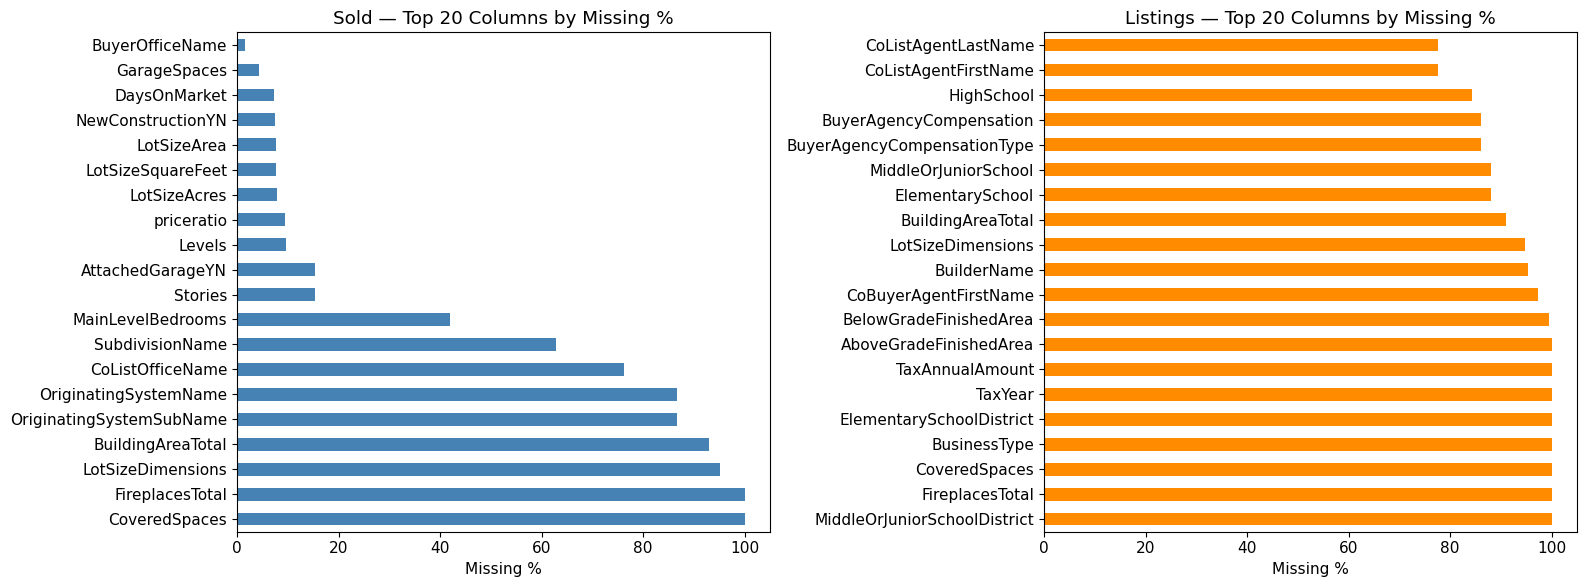

In [19]:
plot_missing_values(sold_missing, list_missing)

### 3f. Outlier Assessment

The  and  fields in the sold dataset already have IQR-based outlier handling applied (outliers replaced with NaN in ). Here we examine the remaining distributions for any additional anomalies in key numeric fields.


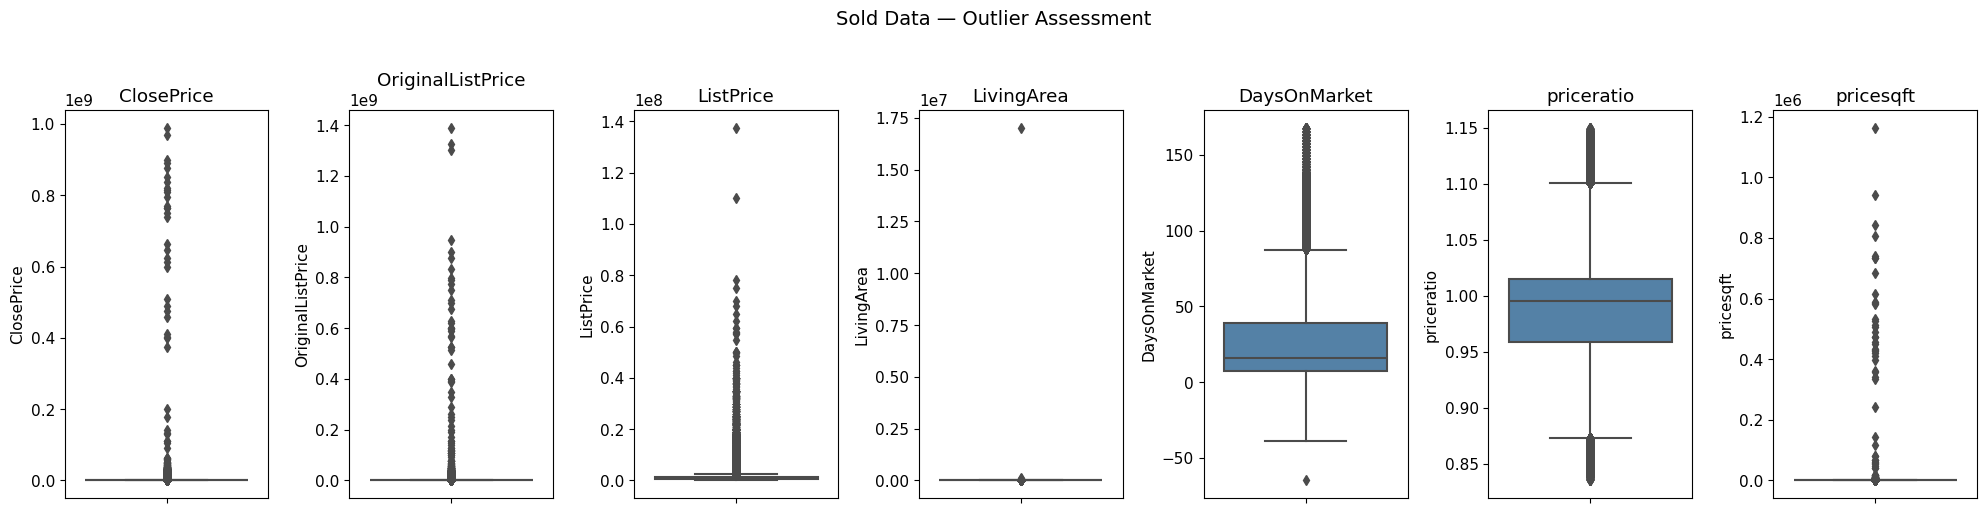

In [20]:
sold_numeric_cols = ['ClosePrice', 'OriginalListPrice', 'ListPrice', 'LivingArea',
                     'DaysOnMarket', 'priceratio', 'pricesqft']
plot_boxplots(sold, sold_numeric_cols, 'Sold Data — Outlier Assessment', color='steelblue')

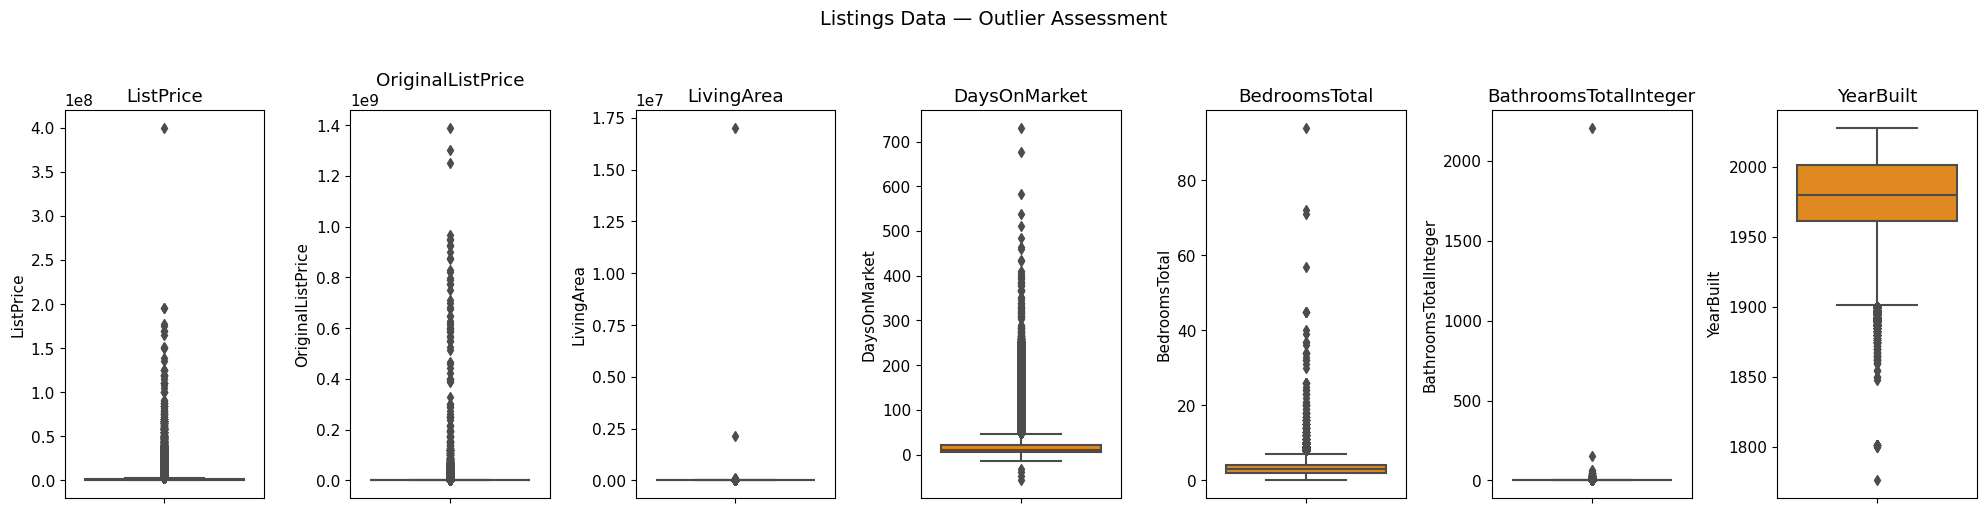

In [21]:
list_numeric_cols = ['ListPrice', 'OriginalListPrice', 'LivingArea', 'DaysOnMarket',
                     'BedroomsTotal', 'BathroomsTotalInteger', 'YearBuilt']
plot_boxplots(listings, list_numeric_cols, 'Listings Data — Outlier Assessment', color='darkorange')

### 3g. Outlier Detection — IQR Filtering

Building on the visual assessment in 3f, formally apply IQR-based outlier filtering to 
`ClosePrice`, `LivingArea`, and `DaysOnMarket`. Flag outliers without deleting them, then 
save both a flagged dataset (full) and a filtered dataset (outliers removed).


In [22]:
# Keep a copy of the pre-filter dataset for comparison
sold_before = sold.copy()

outlier_cols = ['ClosePrice', 'LivingArea', 'DaysOnMarket']
sold_filtered = filter_outliers(sold, outlier_cols)

# Save the flagged (full) dataset and the filtered (clean) dataset
sold.to_csv('../data/sold_flagged.csv', index=False)
sold_filtered.to_csv('../data/sold_filtered.csv', index=False)

print(f'\nSaved sold_flagged.csv:  {len(sold):,} rows (full dataset with outlier flags)')
print(f'Saved sold_filtered.csv: {len(sold_filtered):,} rows (outliers removed)')


ClosePrice: 30,794 outliers flagged (7.4%) — bounds [-512,500.00, 2,387,500.00]
LivingArea: 18,215 outliers flagged (4.4%) — bounds [-208.50, 3,675.50]
DaysOnMarket: 18,599 outliers flagged (4.5%) — bounds [-41.00, 87.00]

Original rows:        414,374
  Invalid (rule):     30,891
  IQR outliers:       54,232
  Combined removed:   80,714
After filtering:      333,660

Saved sold_flagged.csv:  414,374 rows (full dataset with outlier flags)
Saved sold_filtered.csv: 333,660 rows (outliers removed)


### Before/After Comparison

How much did outlier filtering shift the medians and dataset size?


In [23]:
comparison = compare_before_after(sold_before, sold_filtered, outlier_cols)


OUTLIER FILTERING — BEFORE/AFTER COMPARISON
  Rows before: 414,374
  Rows after:  333,660
  Removed:     80,714 (19.48%)
              Median (Before)  Median (After)  Mean (Before)  Mean (After)  Max (Before)  Max (After)
Column                                                                                               
ClosePrice          822944.00       790000.00     1189853.51     903862.47  989500000.00   2387500.00
LivingArea            1642.00         1567.00        1903.72       1672.44   17021321.00      3675.00
DaysOnMarket            16.00           15.00          27.12         23.11        168.00        87.00


---
## 4. Distributions

Examine the shape of key numeric variables to understand skewness, central tendency, and spread. This informs whether we should use median vs. mean for aggregations and whether transformations are needed.


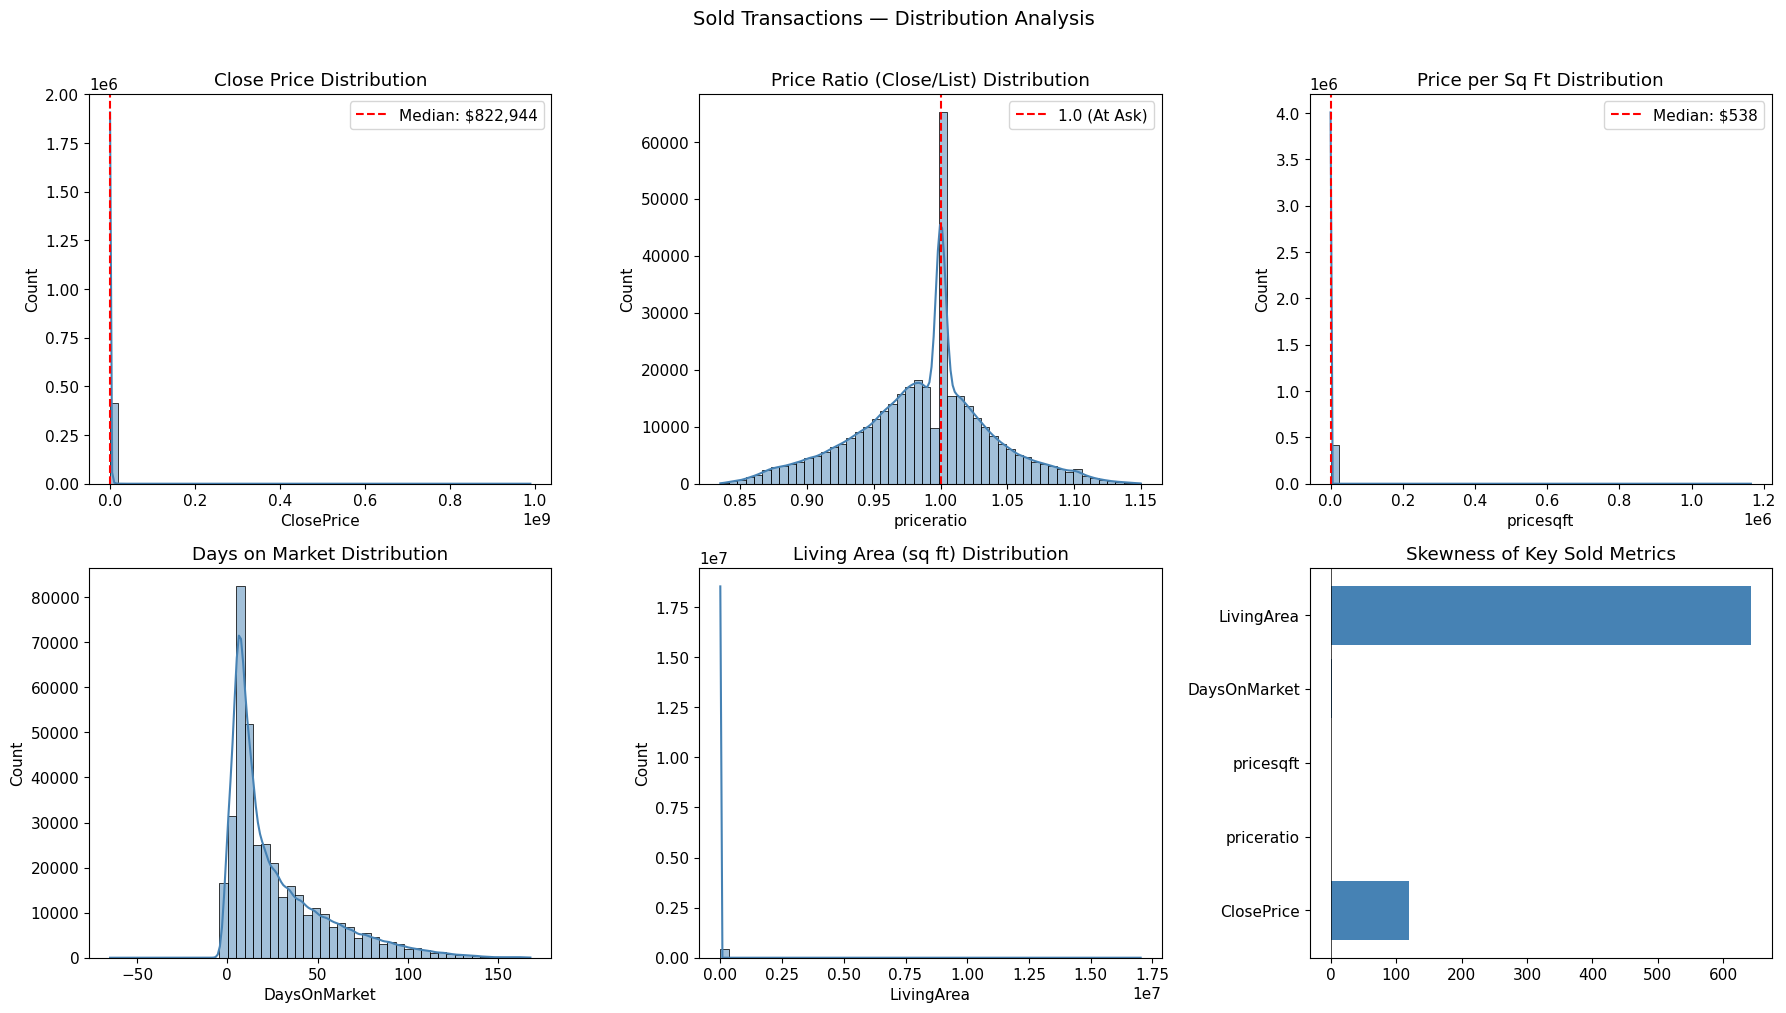

In [24]:
plot_sold_distributions(sold)

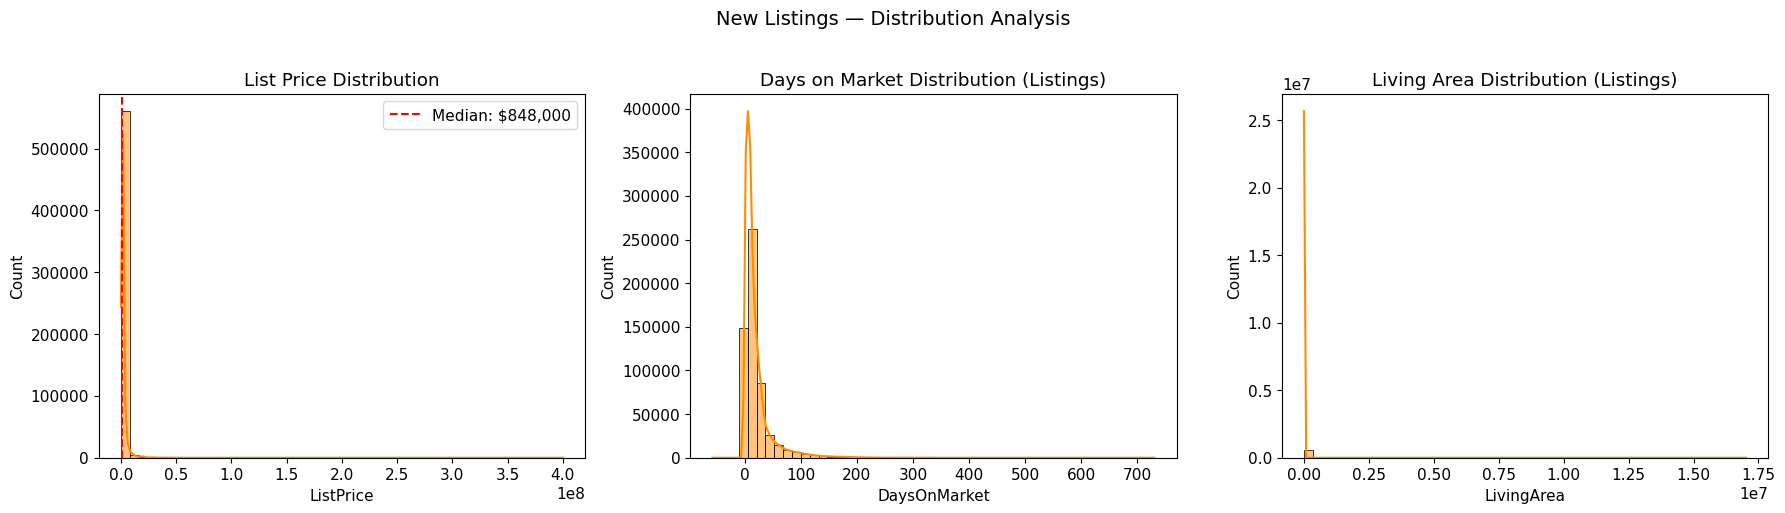

In [25]:
plot_listing_distributions(listings)

### Numeric Distribution Summary

Percentile table for key numeric fields


In [26]:
sold_percentiles = percentile_summary(sold, ['ClosePrice', 'LivingArea', 'DaysOnMarket'])
print('=== Sold Transactions — Numeric Distribution Summary ===')
print(sold_percentiles)
print()

list_percentiles = percentile_summary(listings, ['ListPrice', 'LivingArea', 'DaysOnMarket'])
print('=== New Listings — Numeric Distribution Summary ===')
print(list_percentiles)


=== Sold Transactions — Numeric Distribution Summary ===
                 Count    Min      25th    Median       Mean       75th  \
ClosePrice   414372.00   0.00 575000.00 822944.00 1189853.51 1300000.00   
LivingArea   414140.00   0.00   1248.00   1642.00    1903.72    2219.00   
DaysOnMarket 383840.00 -65.00      7.00     16.00      27.12      39.00   

                      Max  
ClosePrice   989500000.00  
LivingArea    17021321.00  
DaysOnMarket       168.00  

=== New Listings — Numeric Distribution Summary ===
                 Count    Min      25th    Median       Mean       75th  \
ListPrice    566231.00 100.00 580000.00 848000.00 1317075.69 1380000.00   
LivingArea   565655.00   0.00   1248.00   1670.00    1980.47    2301.00   
DaysOnMarket 566231.00 -58.00      5.00     11.00      19.09      22.00   

                      Max  
ListPrice    400000000.00  
LivingArea    17021321.00  
DaysOnMarket       731.00  


---
## 5. Feature Engineering

Create additional features that will be useful for both the EDA and the downstream Tableau dashboards.


In [27]:
sold = engineer_sold_features(sold)

--- Sold Data Features ---
Market condition: {"Buyer's Market": 231055, "Seller's Market": 183319}
Was reduced: {0: 301975, 1: 112399}
DOM buckets: {'0-7': 84666, '8-14': 81139, '15-30': 78401, '31-60': 73086, '61-90': 33691, '90+': 16253}
Price tiers: {'Under 300K': 14224, '300K-500K': 59085, '500K-750K': 106794, '750K-1M': 82334, '1M-2M': 108631, '2M+': 43303}
listing_to_contract_days: median=25 days, mean=45.2 days
contract_to_close_days: median=29 days, mean=31.6 days


In [28]:
listings = engineer_listing_features(listings)

--- Listings Data Features ---
Was reduced: {0: 473019, 1: 93212}
Price tiers: {'Under 300K': 19104, '300K-500K': 82336, '500K-750K': 139923, '750K-1M': 110563, '1M-2M': 144477, '2M+': 69828}


### Segment Analysis

Group key metrics by market dimensions to uncover patterns across property types, geographies, and offices.


In [29]:
# Segment by PropertySubType
segment_summary(sold, 'PropertySubType')



=== Segment Summary by PropertySubType (top 20) ===
                       homes_sold  median_price  avg_dom  avg_priceratio  median_pricesqft  median_listing_to_contract  median_contract_to_close
PropertySubType                                                                                                                                 
SingleFamilyResidence      309963     893450.00    26.27            0.99            532.85                       23.00                     29.00
Condominium                 68536     628000.00    30.75            0.98            565.17                       29.00                     28.00
Townhouse                   24303     804000.00    26.13            0.99            562.13                       21.00                     28.00
ManufacturedOnLand           5350     324999.50    32.55            0.97            225.69                       39.00                     34.00
Duplex                       2267     915000.00    28.82            0.98     

,homes_sold,median_price,avg_dom,avg_priceratio,median_pricesqft,median_listing_to_contract,median_contract_to_close
PropertySubType,,,,,,,
SingleFamilyResidence,309963,893450.00,26.27,0.99,532.85,23.00,29.00
Condominium,68536,628000.00,30.75,0.98,565.17,29.00,28.00
Townhouse,24303,804000.00,26.13,0.99,562.13,21.00,28.00
ManufacturedOnLand,5350,324999.50,32.55,0.97,225.69,39.00,34.00
Duplex,2267,915000.00,28.82,0.98,545.10,31.00,32.00
StockCooperative,1661,360000.00,27.98,0.98,395.83,31.00,45.00
Cabin,470,238000.00,39.38,0.96,287.76,56.00,30.00
Triplex,339,1105000.00,35.00,0.97,466.42,44.00,36.00
MixedUse,206,700000.00,42.76,0.97,435.54,67.00,32.00


In [30]:
# Segment by CountyOrParish
segment_summary(sold, 'CountyOrParish')



=== Segment Summary by CountyOrParish (top 20) ===
                 homes_sold  median_price  avg_dom  avg_priceratio  median_pricesqft  median_listing_to_contract  median_contract_to_close
CountyOrParish                                                                                                                            
Los Angeles          102971     900000.00    27.41            0.99            608.61                       25.00                     30.00
Riverside             57416     600000.00    33.58            0.98            321.30                       38.00                     29.00
San Diego             51258     899000.00    24.19            0.99            591.25                       21.00                     26.00
Orange                46621    1175000.00    24.50            0.99            672.79                       25.00                     29.00
San Bernardino        38612     530000.00    30.68            0.99            332.07                       32.00  

,homes_sold,median_price,avg_dom,avg_priceratio,median_pricesqft,median_listing_to_contract,median_contract_to_close
CountyOrParish,,,,,,,
Los Angeles,102971,900000.00,27.41,0.99,608.61,25.00,30.00
Riverside,57416,600000.00,33.58,0.98,321.30,38.00,29.00
San Diego,51258,899000.00,24.19,0.99,591.25,21.00,26.00
Orange,46621,1175000.00,24.50,0.99,672.79,25.00,29.00
San Bernardino,38612,530000.00,30.68,0.99,332.07,32.00,32.00
Alameda,19544,1132800.00,21.83,1.00,701.08,14.00,23.00
Contra Costa,18833,820000.00,23.74,0.99,520.52,15.00,23.00
Santa Clara,18447,1600000.00,18.33,1.01,966.49,9.00,25.00
Ventura,12898,869000.00,32.55,0.98,516.30,34.00,24.00


In [31]:
# Segment by ListOfficeName (competitive intelligence)
segment_summary(sold, 'ListOfficeName')



=== Segment Summary by ListOfficeName (top 20) ===
                                                       homes_sold  median_price  avg_dom  avg_priceratio  median_pricesqft  median_listing_to_contract  median_contract_to_close
ListOfficeName                                                                                                                                                                  
Compass                                                     29130    1350000.00    23.86            0.99            757.96                       17.00                     25.00
Coldwell Banker Realty                                      18700    1195000.00    25.57            0.99            695.04                       21.00                     25.00
Keller Williams Realty                                       8132     870000.00    24.36            0.99            540.33                       21.00                     28.00
First Team Real Estate                                       57

,homes_sold,median_price,avg_dom,avg_priceratio,median_pricesqft,median_listing_to_contract,median_contract_to_close
ListOfficeName,,,,,,,
Compass,29130,1350000.00,23.86,0.99,757.96,17.00,25.00
Coldwell Banker Realty,18700,1195000.00,25.57,0.99,695.04,21.00,25.00
Keller Williams Realty,8132,870000.00,24.36,0.99,540.33,21.00,28.00
First Team Real Estate,5797,960000.00,22.84,0.99,609.11,26.00,29.00
Berkshire Hathaway HomeServices California Properties,5483,950000.00,30.10,0.98,598.53,29.00,28.00
eXp Realty of California Inc,4826,789950.00,27.30,0.99,532.12,25.00,29.00
Real Broker,4728,845000.00,24.52,0.99,557.84,24.00,28.00
Intero Real Estate Services,4518,1375000.00,20.27,1.01,847.56,11.00,25.00
"eXp Realty of California, Inc.",3594,760000.00,22.48,1.00,495.07,21.00,27.00


In [32]:
# Segment by BuyerOfficeName
segment_summary(sold, 'BuyerOfficeName')



=== Segment Summary by BuyerOfficeName (top 20) ===
                                                       homes_sold  median_price  avg_dom  avg_priceratio  median_pricesqft  median_listing_to_contract  median_contract_to_close
BuyerOfficeName                                                                                                                                                                 
Compass                                                     27214    1325000.00    24.38            0.99            751.98                       18.00                     25.00
Coldwell Banker Realty                                      14962    1195000.00    25.19            0.99            689.19                       21.00                     26.00
NONMEMBER MRML                                               8835     503580.00    32.00            0.98            289.86                       34.00                     31.00
Keller Williams Realty                                       6

,homes_sold,median_price,avg_dom,avg_priceratio,median_pricesqft,median_listing_to_contract,median_contract_to_close
BuyerOfficeName,,,,,,,
Compass,27214,1325000.00,24.38,0.99,751.98,18.00,25.00
Coldwell Banker Realty,14962,1195000.00,25.19,0.99,689.19,21.00,26.00
NONMEMBER MRML,8835,503580.00,32.00,0.98,289.86,34.00,31.00
Keller Williams Realty,6378,835000.00,26.20,0.99,534.18,24.00,27.00
Real Broker,6169,800000.00,26.67,0.99,541.80,25.00,27.00
eXp Realty of California Inc,5282,835000.00,28.03,0.99,570.02,25.00,28.00
First Team Real Estate,5240,900000.00,24.08,0.99,597.52,25.00,28.00
"eXp Realty of California, Inc.",4707,730000.00,26.41,0.99,494.61,26.00,27.00
Berkshire Hathaway HomeServices California Properties,4262,975000.00,28.58,0.98,607.75,27.00,28.00


---
## 6. Exploratory Data Analysis

### 6a. Market Trends Over Time

These monthly time-series views mirror the KPIs tracked in the CA Market Analysis Tableau dashboard: median sales price, price per square foot, days on market, and sold/list price ratio.


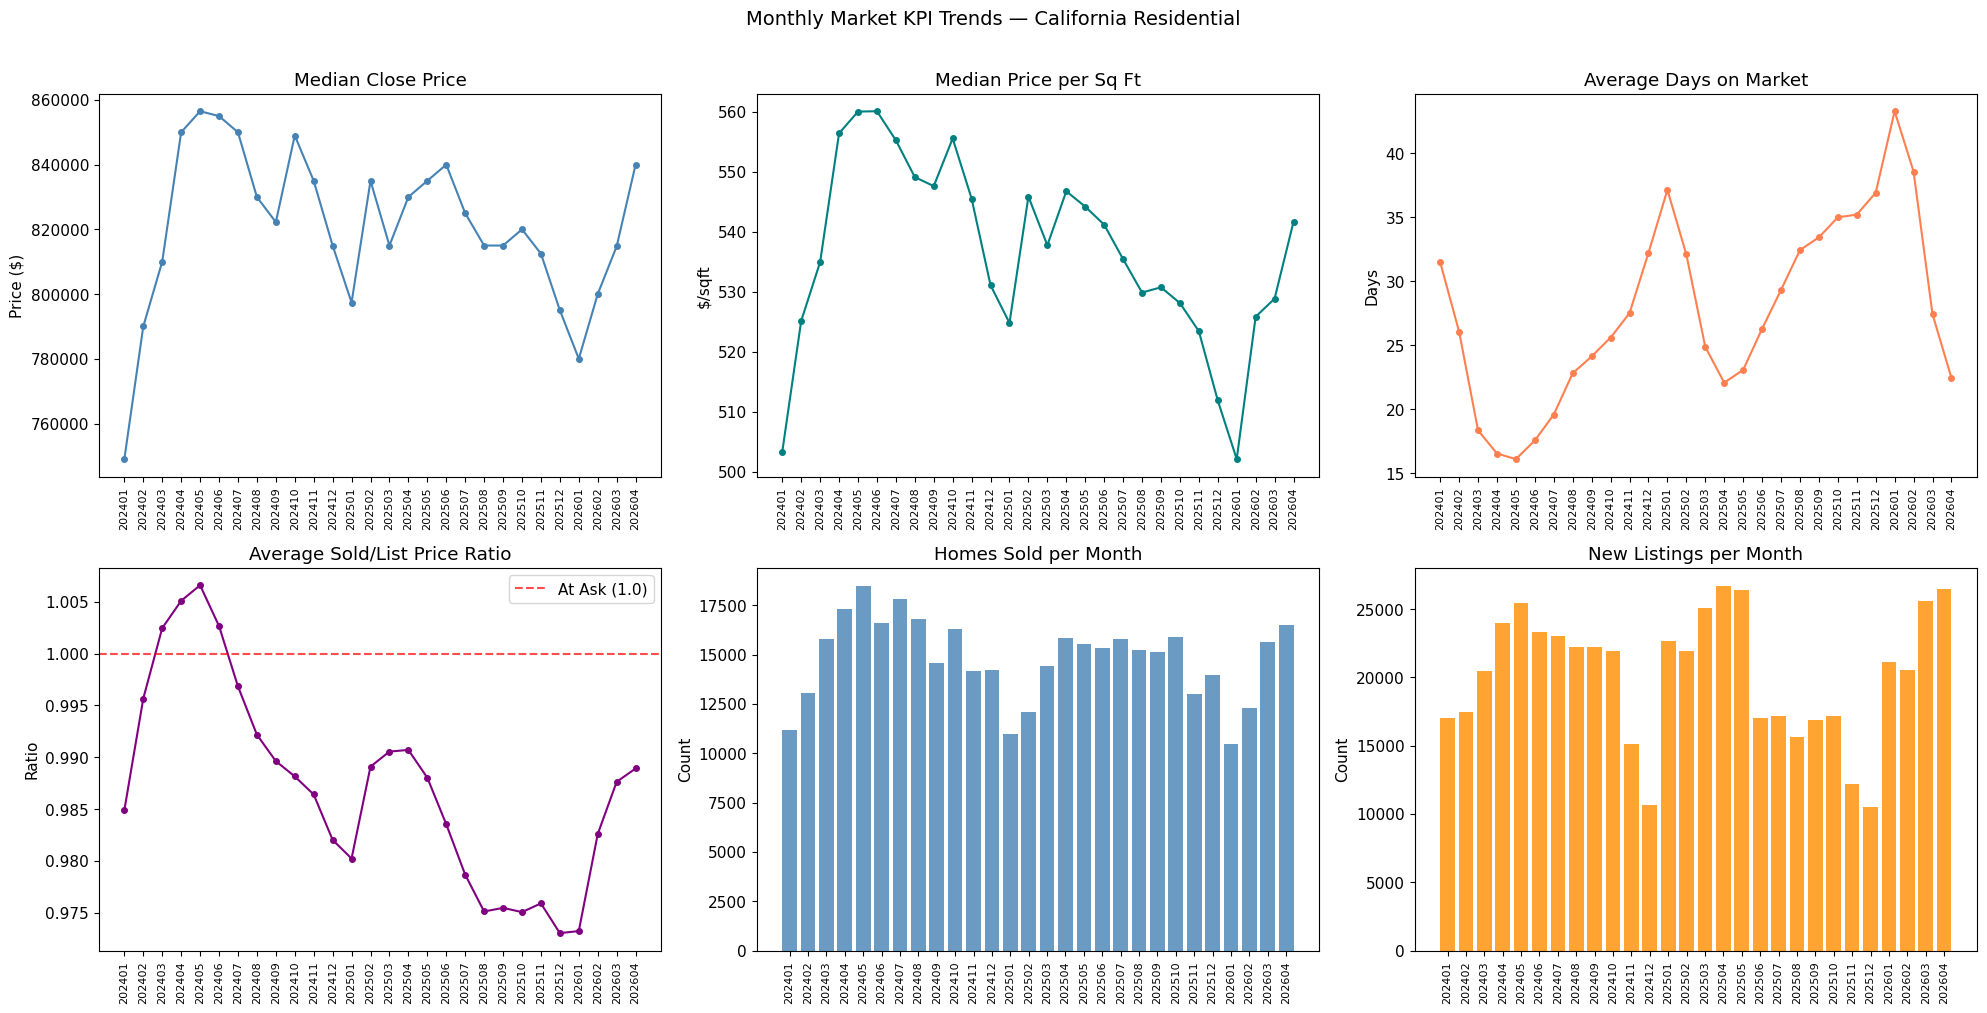

In [33]:
monthly_sold = monthly_sold_summary(sold)
monthly_listings = monthly_listing_summary(listings)
plot_monthly_kpi_trends(monthly_sold, monthly_listings)

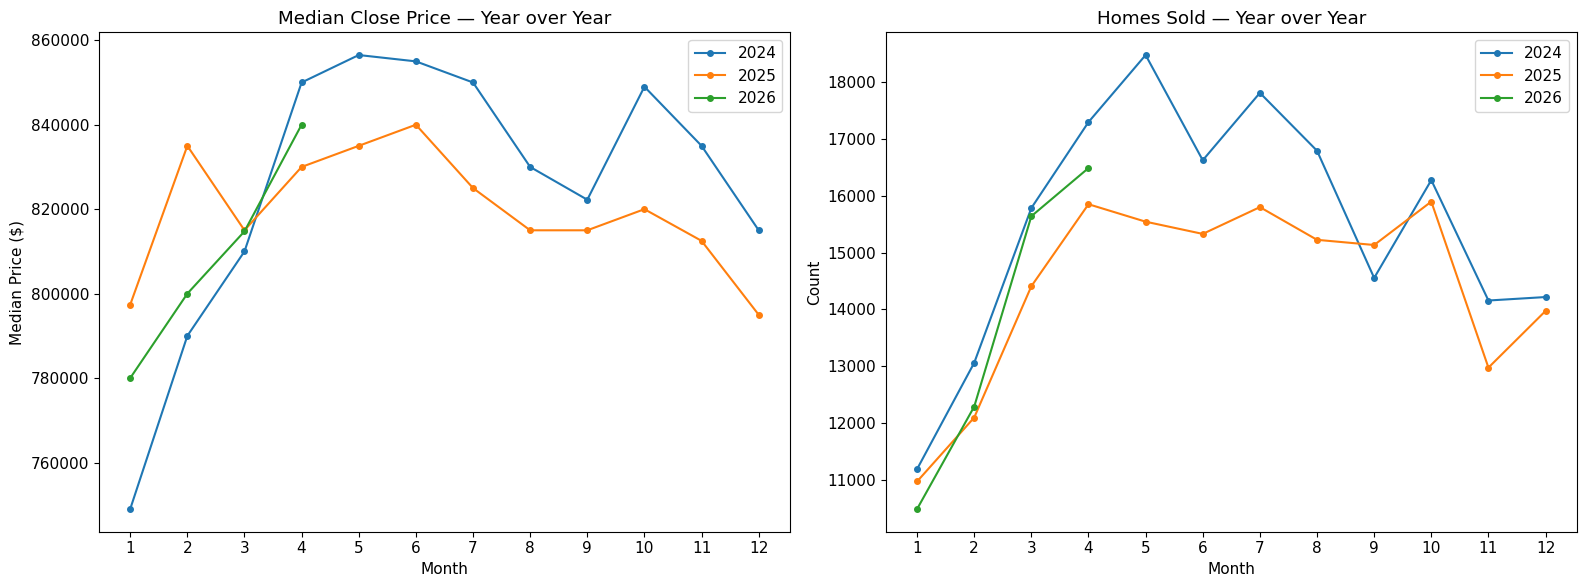

In [34]:
plot_yoy_comparison(sold)

### 6b. Supply vs. Demand

Compare new listing volume to closed sales volume over time. The ratio of these two indicates market tightness — a rising ratio means more inventory relative to demand.


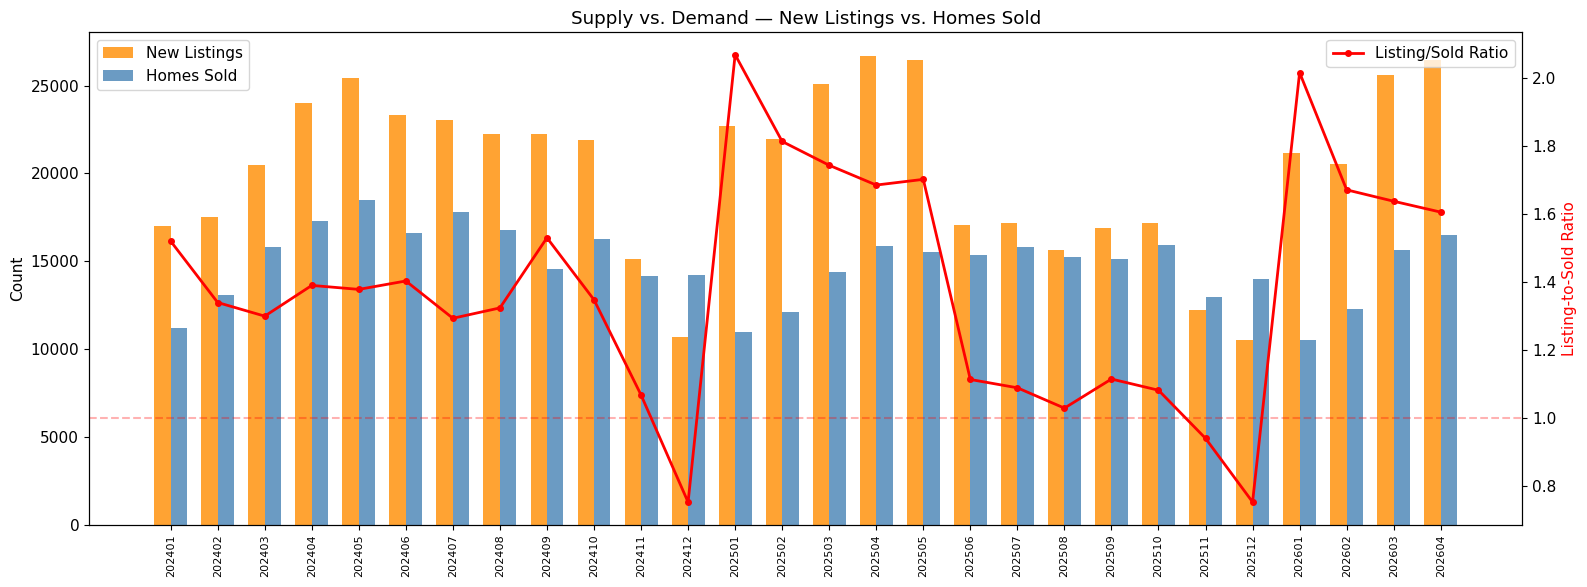

In [35]:
plot_supply_vs_demand(monthly_sold, monthly_listings)

### 6c. Geographic Analysis

Analyze market performance at the county and city level — the primary geographic dimensions used in the Tableau market analysis dashboard.


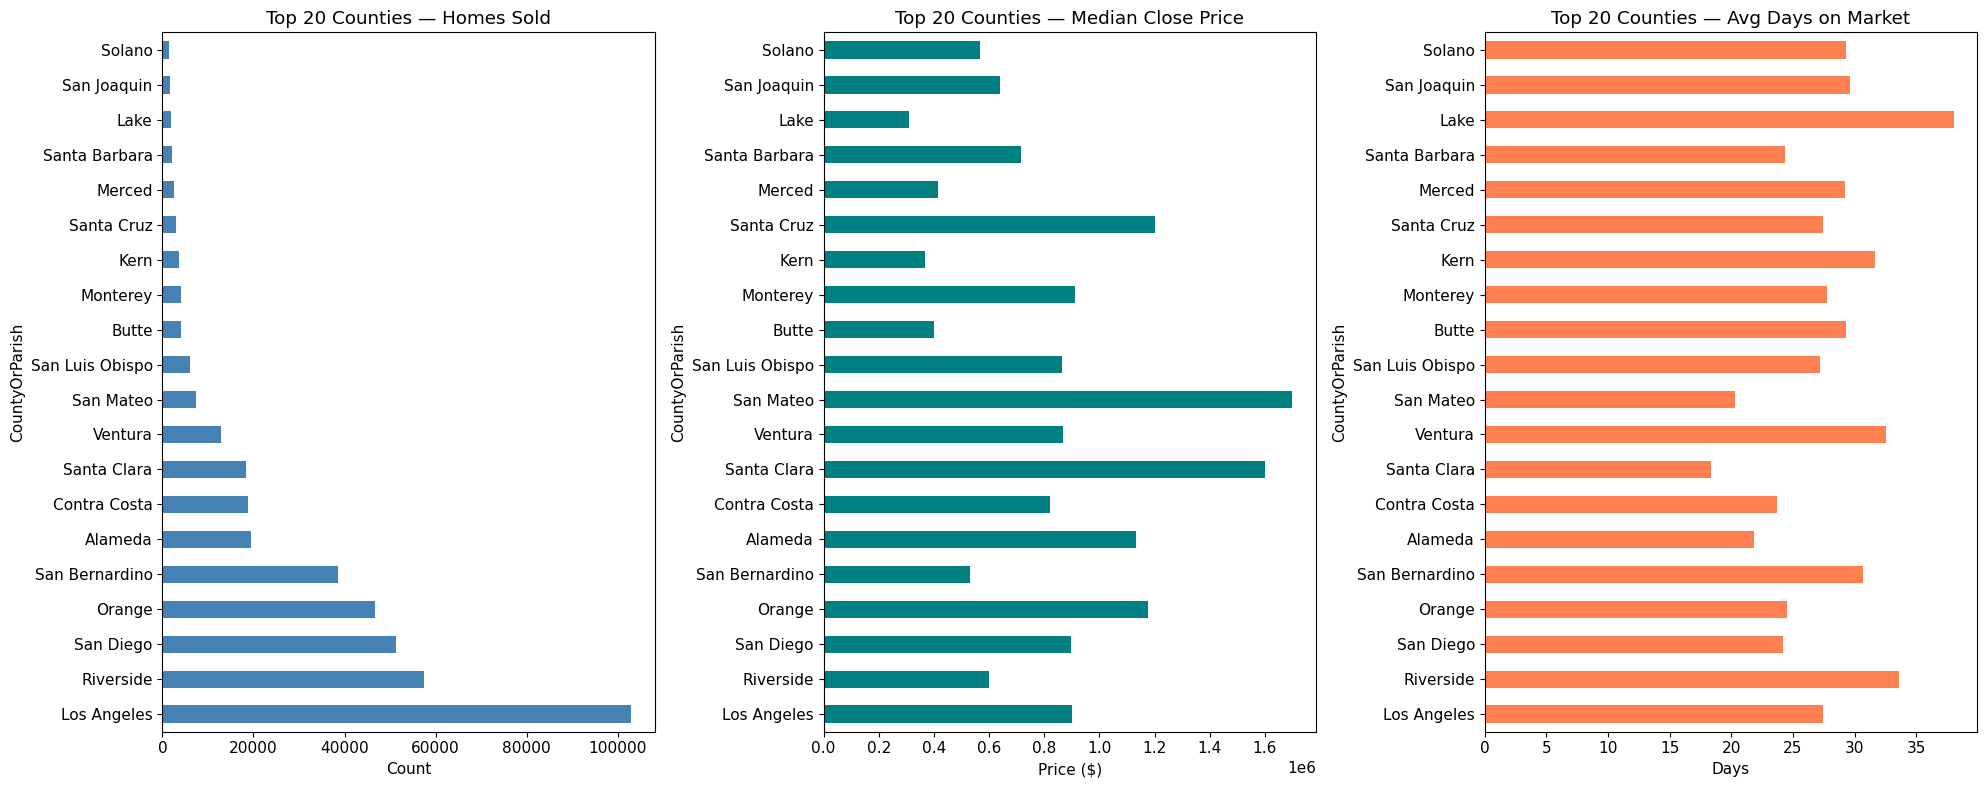

In [36]:
county_stats = geographic_summary(sold, 'CountyOrParish')
plot_top_counties(county_stats)

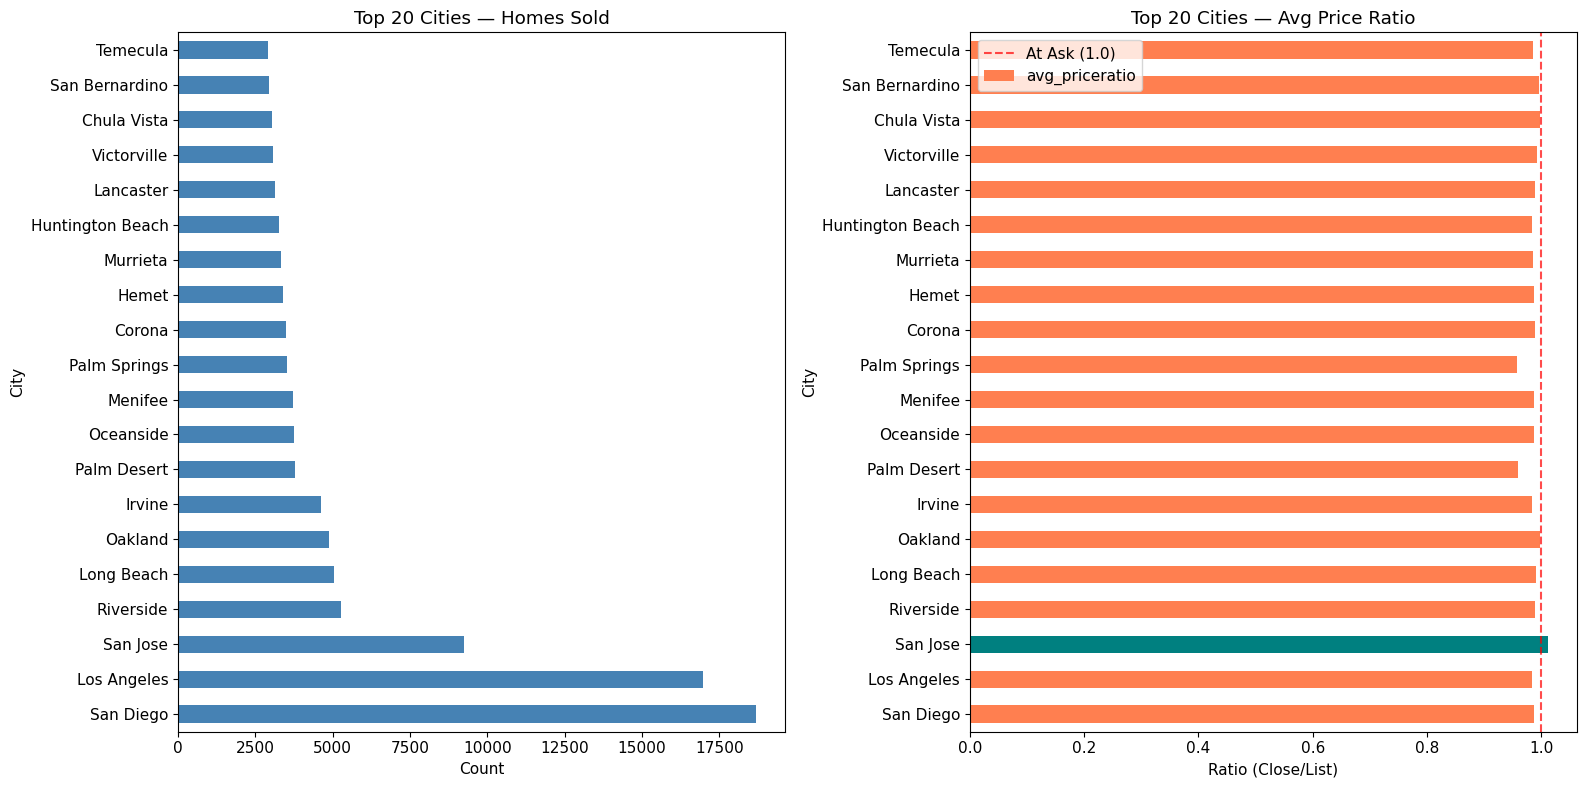

In [37]:
city_stats = geographic_summary(sold, 'City')
plot_top_cities(city_stats)

### 6d. Property Characteristics and Pricing Relationships

Explore how property attributes (size, bedrooms, year built, property subtype) relate to price and market velocity.


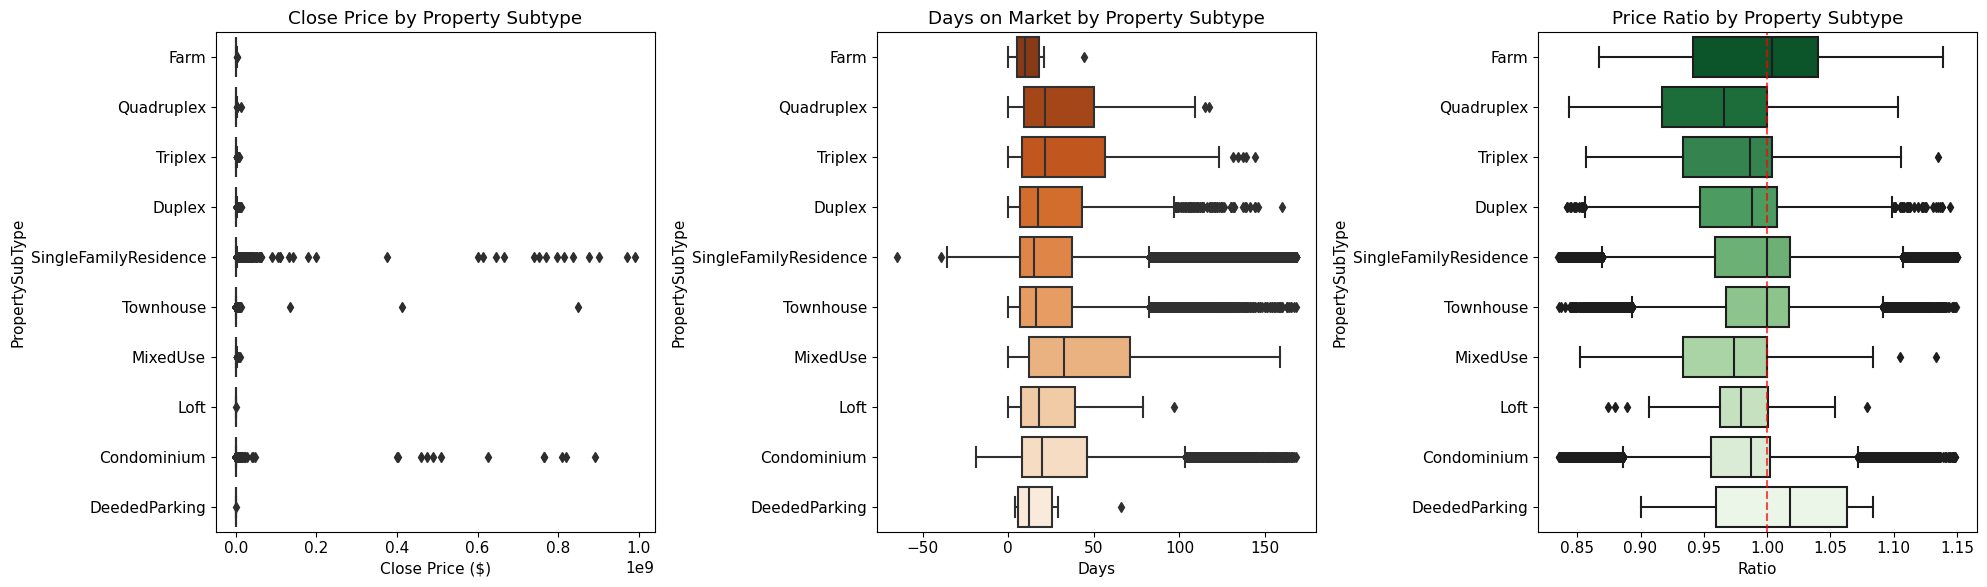

In [38]:
plot_subtype_comparison(sold)

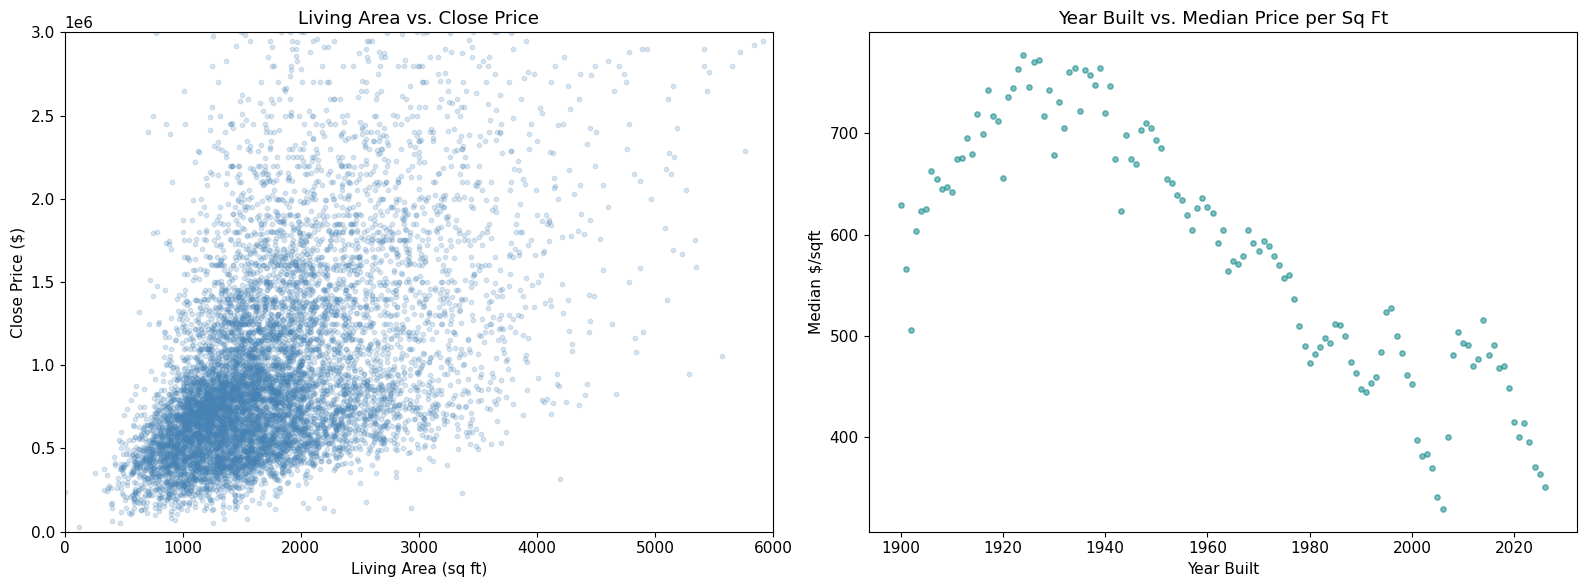

In [39]:
plot_price_vs_size(sold)

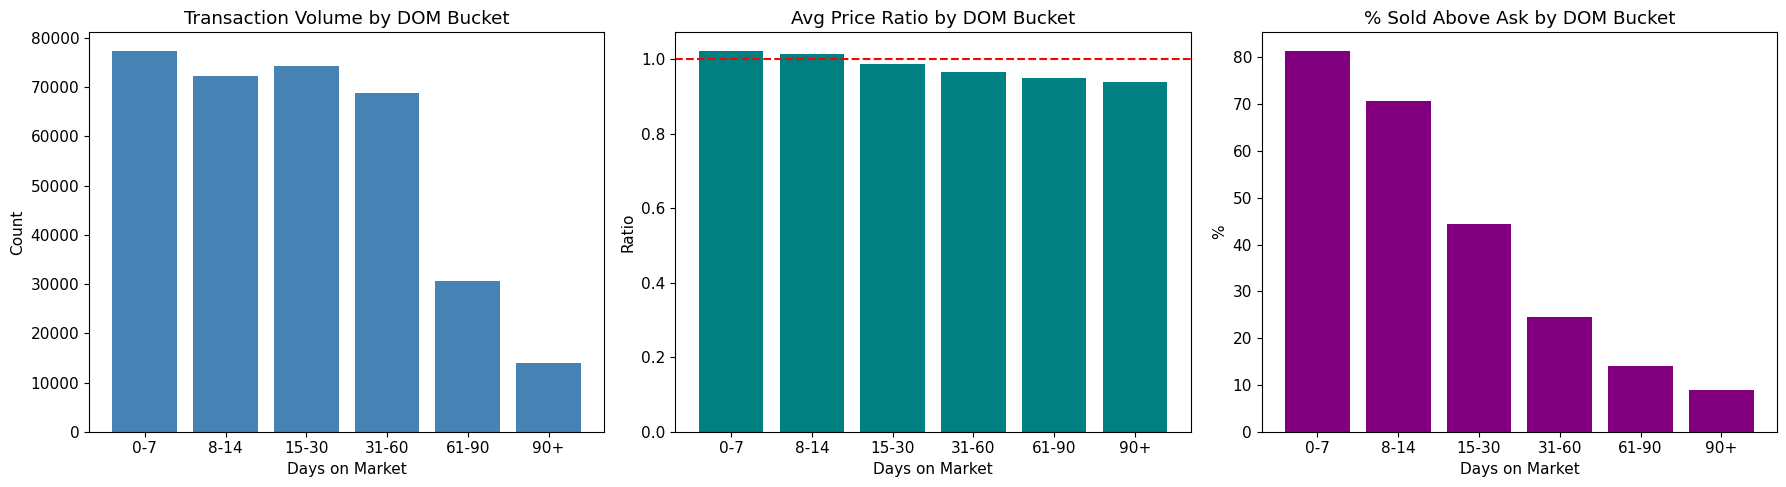

In [40]:
dom_analysis = dom_bucket_summary(sold)
plot_dom_bucket_analysis(dom_analysis)

### 6e. Price Reductions Analysis

Examine the prevalence and magnitude of price reductions across markets. High reduction rates signal softening demand — a key indicator for the market analysis dashboard.


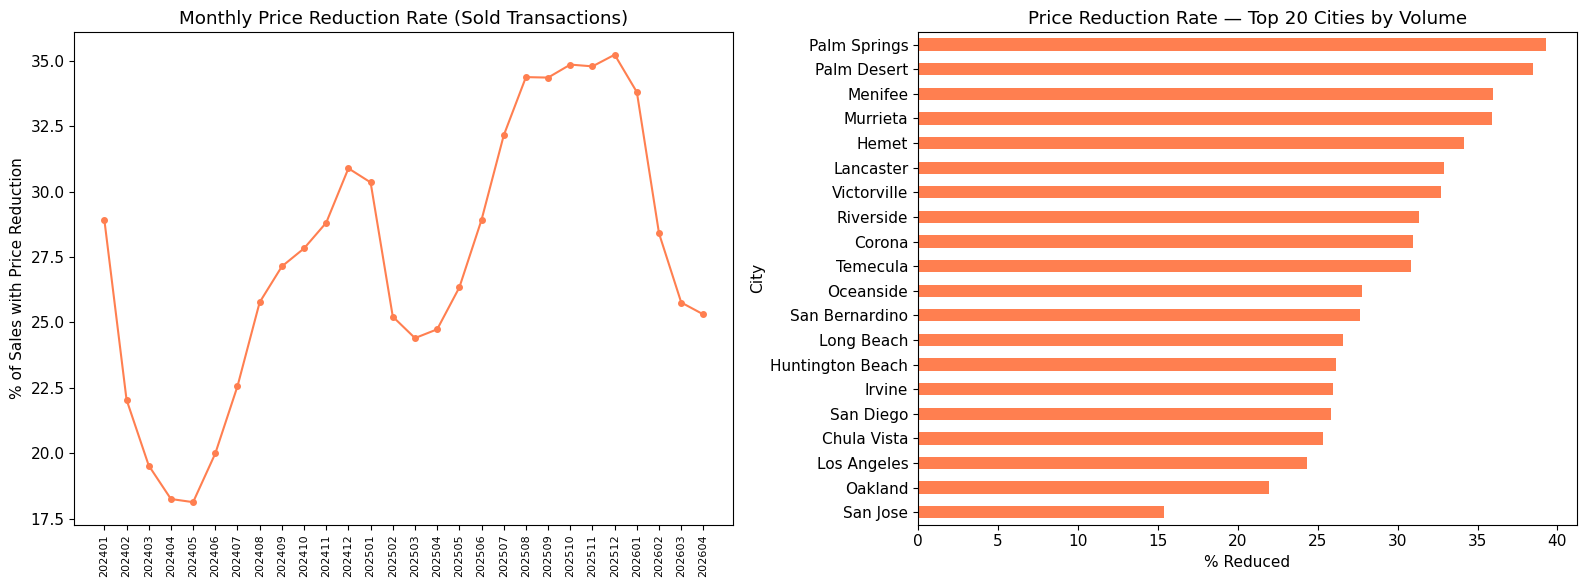

In [41]:
plot_price_reductions(sold)

### 6f. Competitive Analysis — Agent and Office Performance

Preliminary analysis of listing agent and office performance. These metrics feed directly into the Agent/Office Report Tableau dashboard.


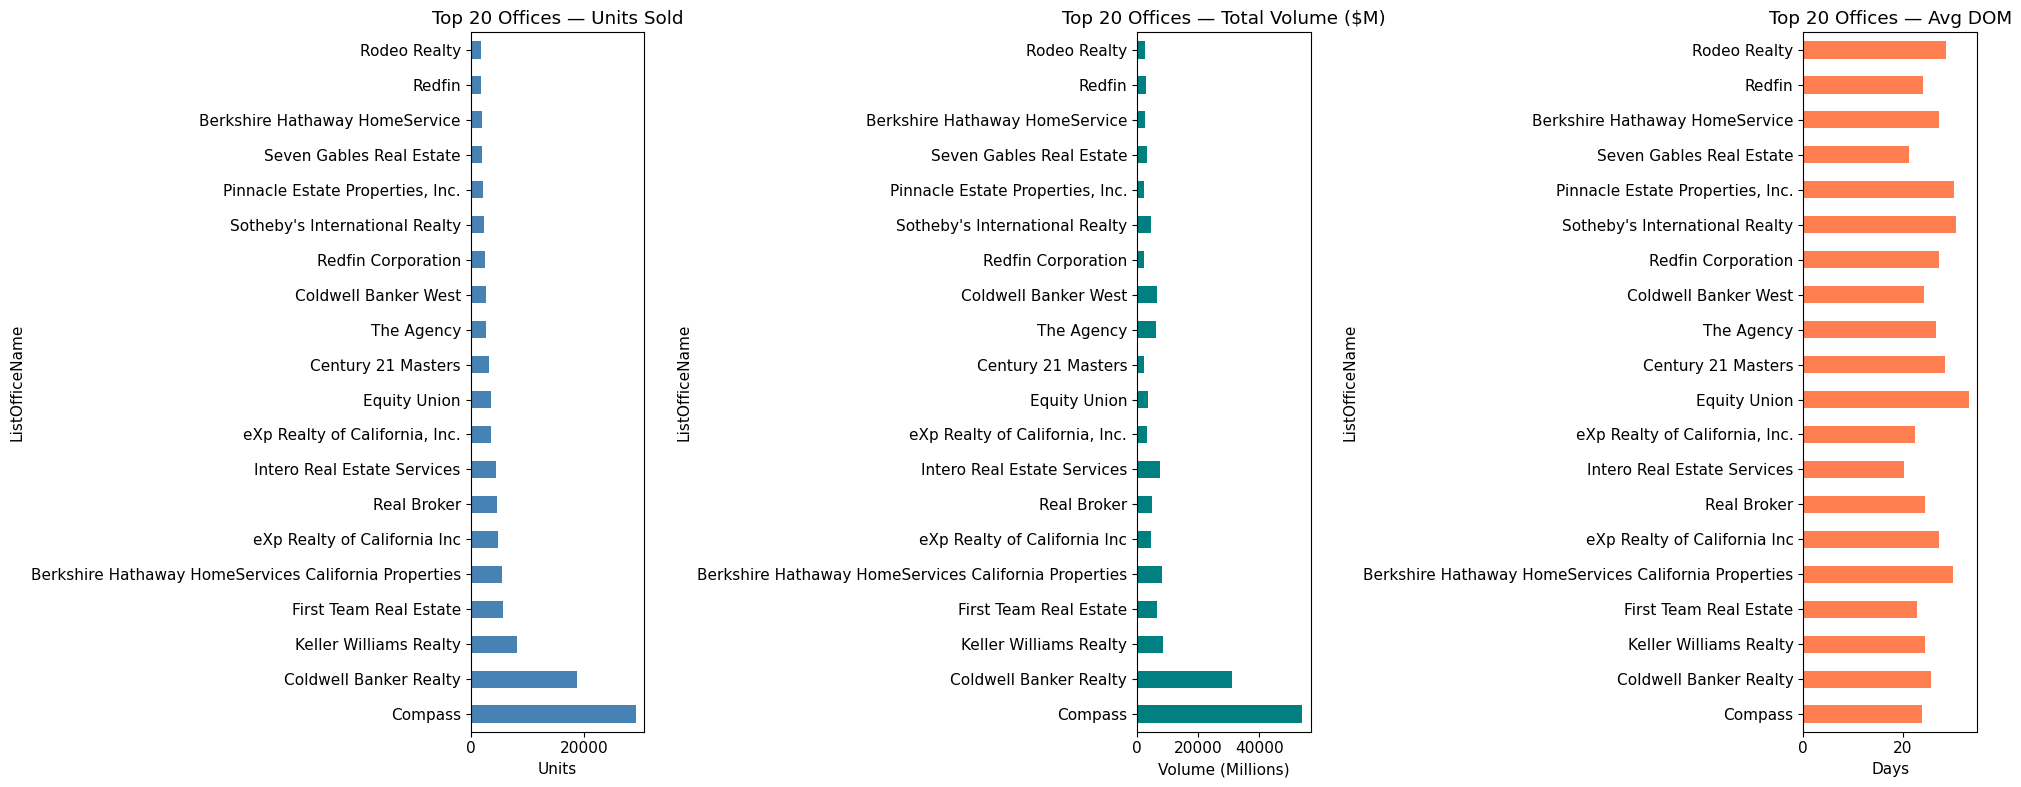

In [42]:
office_stats = competitive_summary(sold, 'ListOfficeName')
plot_top_offices(office_stats)

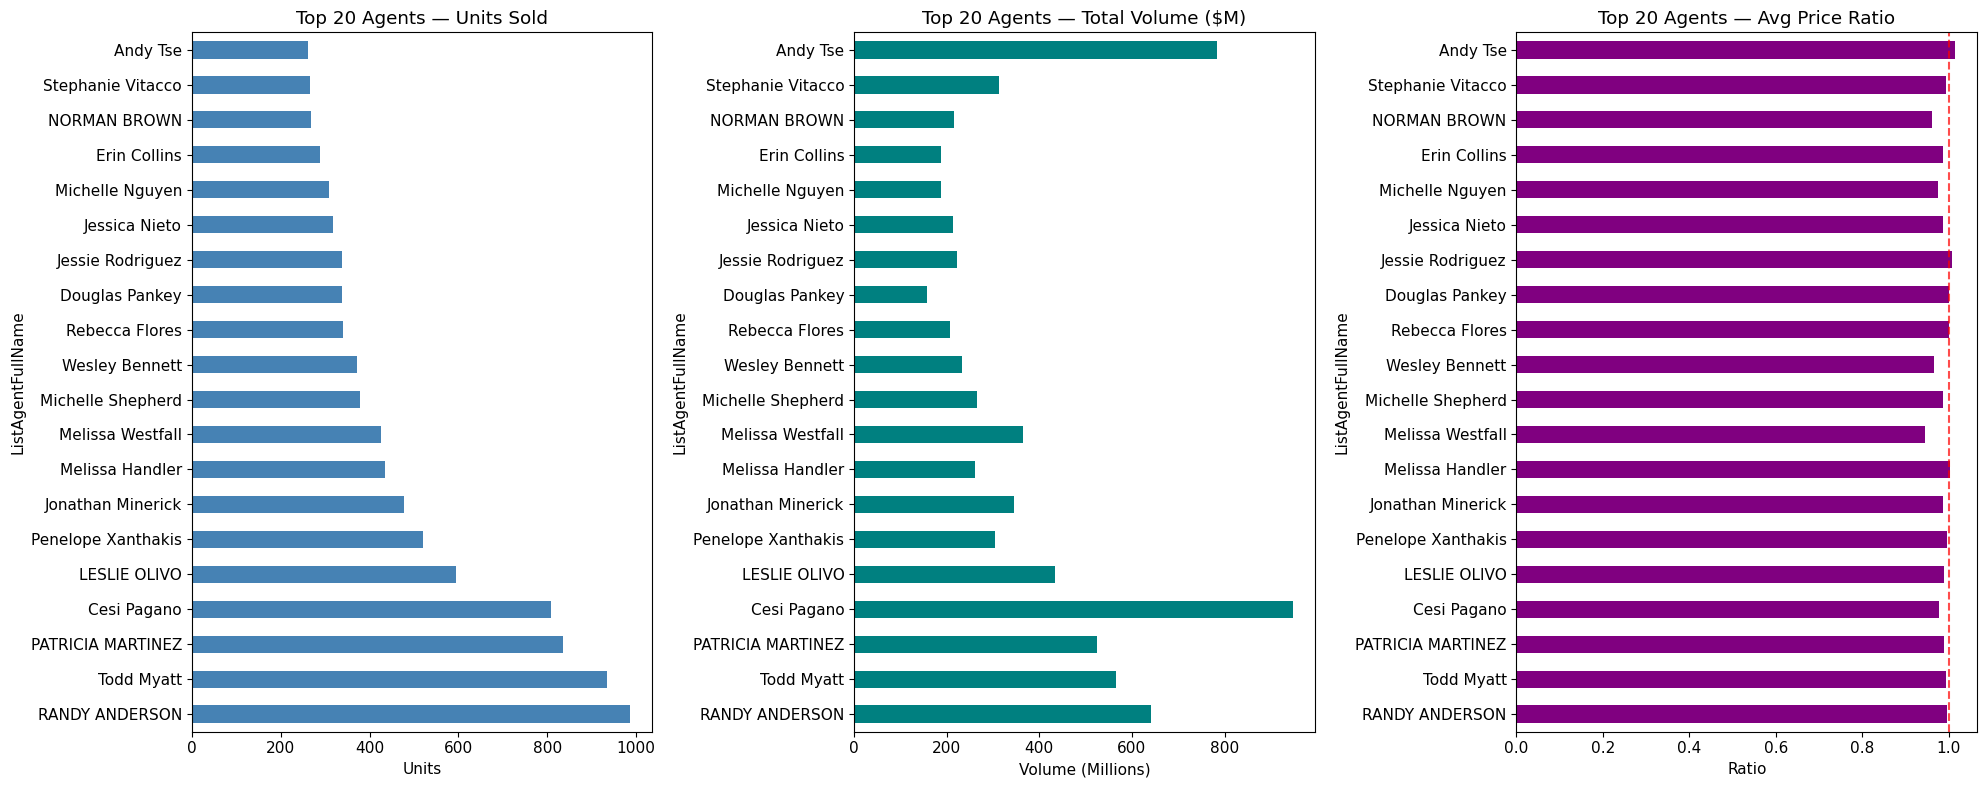

In [43]:
agent_stats = competitive_summary(sold, 'ListAgentFullName')
plot_top_agents(agent_stats)

### 6g. Correlation Analysis

Examine linear relationships between key numeric variables in the sold dataset to identify which features are most predictive of price, market velocity, and competitiveness.


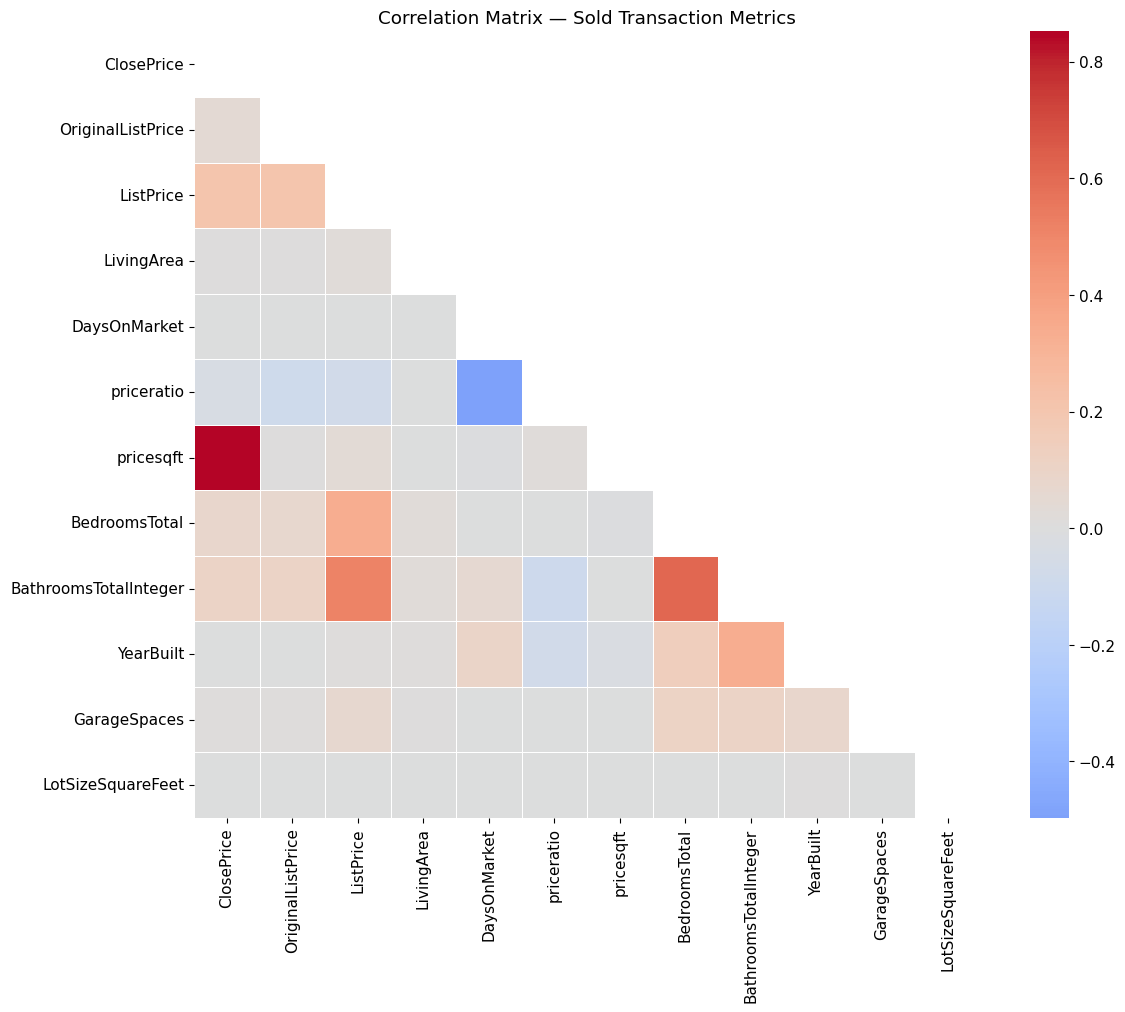

In [44]:
plot_correlation_heatmap(sold)

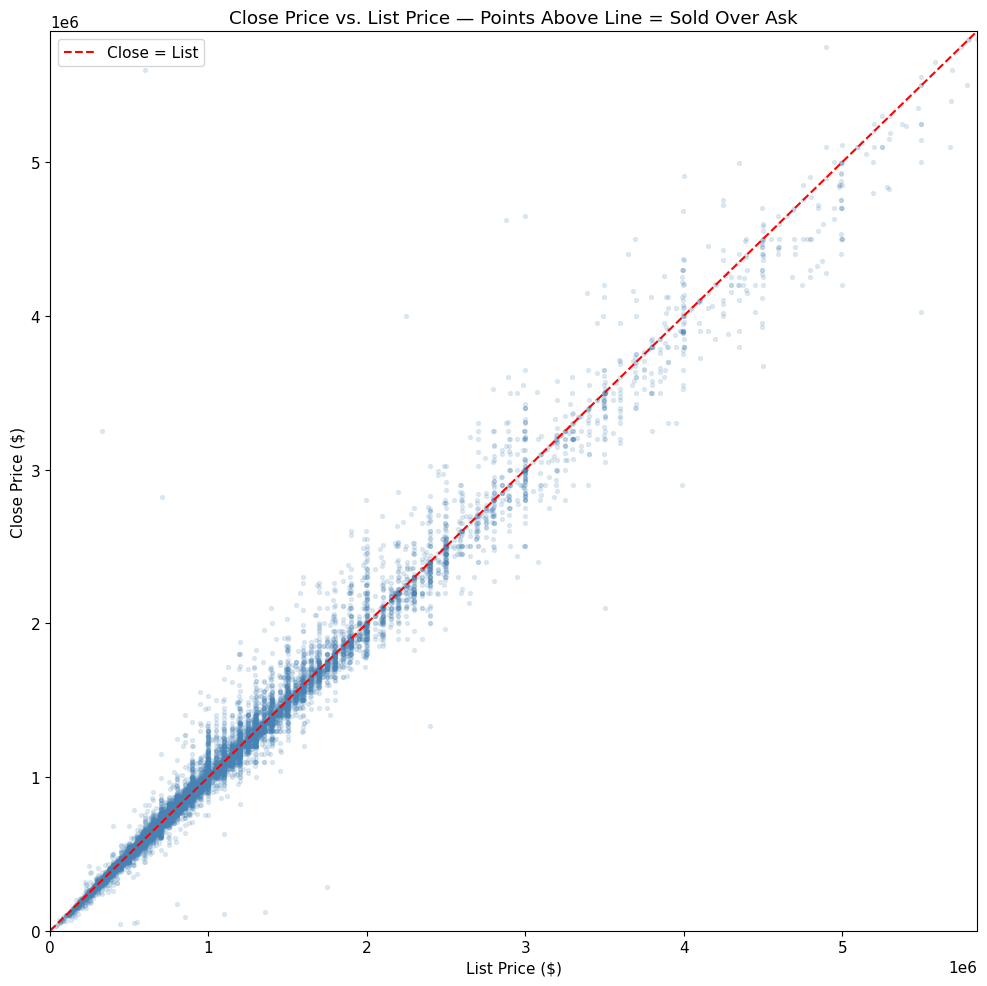

In [45]:
plot_close_vs_list(sold)

### 6h. Price Tier Analysis

Break down key metrics by price segment to understand how market dynamics differ across price points.


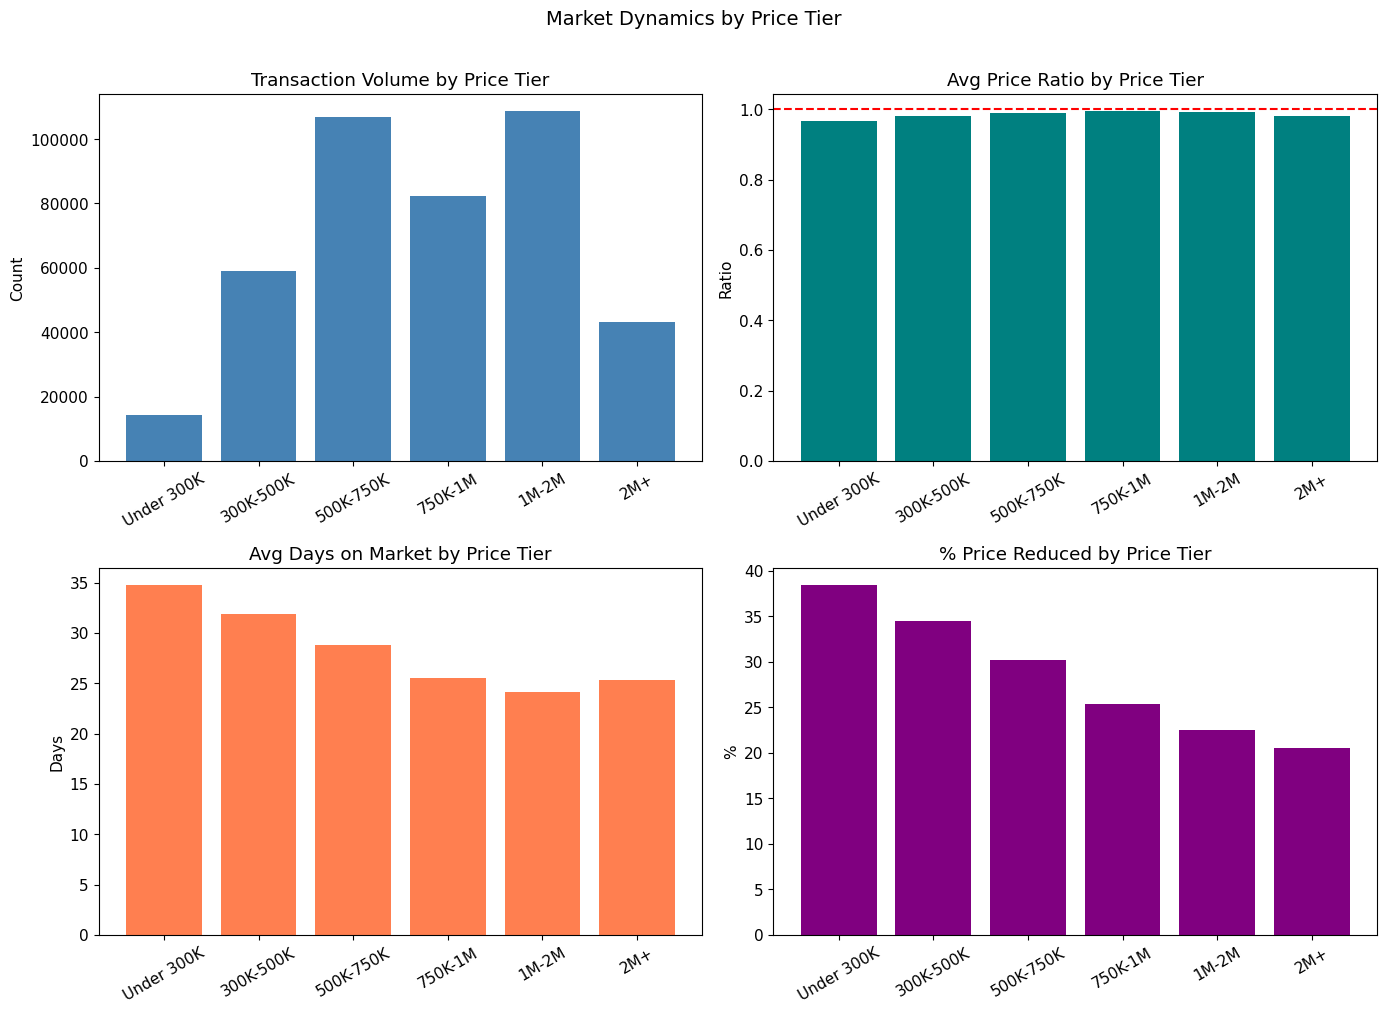

In [46]:
tier_stats = price_tier_summary(sold)
plot_price_tiers(tier_stats)

### 6i. New Construction vs. Existing Homes

New Construction vs. Existing Homes:
                    count  median_price  median_pricesqft  avg_dom  avg_priceratio
NewConstructionYN                                                                 
False              368010     825000.00            543.69    26.71            0.99
True                15579     666089.00            349.10    36.34            0.99


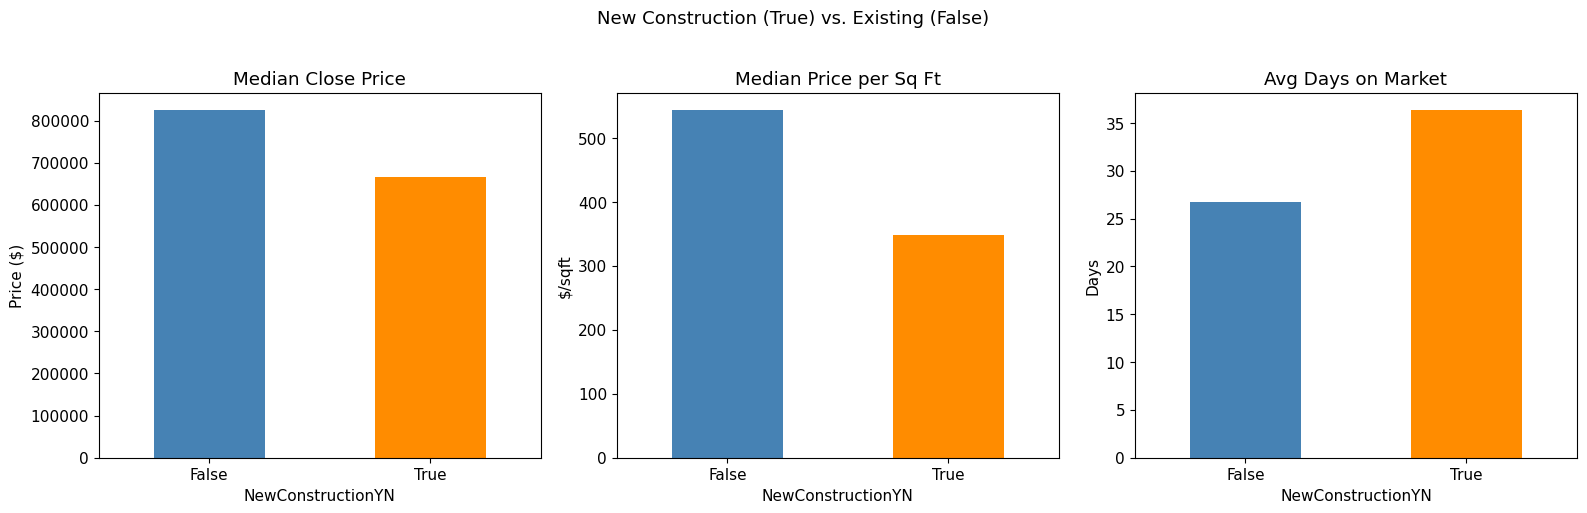

In [47]:
plot_new_construction(sold)

---
## 7. Summary Statistics for Tableau

Generate a concise summary table of the key metrics that will populate the Tableau dashboards.


In [48]:
market_summary(sold, listings)

CALIFORNIA RESIDENTIAL MARKET SUMMARY
Period: 2024-01-01 to 2026-04-30
Total closed transactions:    414,374
Total new listings:           566,231
Median close price:           $822,944
Median price per sq ft:       $538
Avg days on market:           27.1
Avg sold/list price ratio:    0.9878
% sold above ask:             44.2%
% with price reduction:       27.1%
Unique cities:                1129
Unique counties:              63
Unique ZIP codes:             3684
Unique listing offices:       18680
Unique listing agents:        77979


---
## 8. Key Findings

This section walks through the project chronologically — what we worked with, how we cleaned and enriched it, what features we built, what the analysis revealed, and why it matters for the Tableau dashboards.

---

### 1. The Dataset
- **414,374 closed sold transactions and 566,231 new listings** across 28 months (Jan 2024 — Apr 2026).
- Source: California Regional MLS (CRMLS) via the CoreLogic Trestle API, pre-filtered to Residential property types only.
- **63 counties, 1,129 cities, 3,684 ZIP codes** — full statewide coverage.
- **18,680 listing offices and 77,979 listing agents** — broad competitive landscape.
- **Significance:** A large, multi-year, geographically diverse dataset that supports both market trend analysis and competitive intelligence at the agent/office level.

### 2. Data Cleaning & Preparation

**Mortgage Rate Enrichment (Weeks 2-3):**
- Merged the FRED 30-year fixed mortgage rate (MORTGAGE30US) onto both datasets at monthly granularity.
- Zero null values after merge — full coverage from Jan 2024 through Apr 2026.
- **Significance:** Allows Tableau dashboards to overlay rate trends (~6.3%–7.5% over this period) on volume and price views, providing economic context for market activity.

**Date Consistency, Validation, and Geographic Checks (Weeks 4-5):**
- **Date consistency:** 298 records (0.07%) flagged with timeline violations — 61 listing-after-close, 239 purchase-after-close.
- **Invalid numerics (sold):** 190 records flagged (0.05%) — 1 ClosePrice ≤ 0, 150 LivingArea ≤ 0, 39 negative DOM.
- **Geographic issues:** 4,269 sold (1.03%) and 80,763 listings (14.3%) flagged — primarily missing coordinates.
- All flags are additive (no rows deleted), preserving the full dataset for downstream use.
- **Significance:** Confirms the dataset is high quality (<1% bad records on sold side), but the listings dataset has a notable geocoding gap that may affect zip-code heat maps in Tableau.

**Outlier Detection — IQR Filtering (Week 7):**
- **ClosePrice:** 30,794 outliers flagged (7.4%) outside [-$512K, $2.39M] — caught a $989M data entry error in the max.
- **LivingArea:** 18,215 outliers flagged (4.4%) outside [-208, 3,676 sqft] — caught the 17M sqft data error.
- **DaysOnMarket:** 18,599 outliers flagged (4.5%) outside [-41, 87 days] — caught negative DOM and extreme long-tail values.
- **Combined removal:** 80,714 rows (19.48%) — 30,891 invalid by business rule + 54,232 IQR outliers (with overlap).
- **Final filtered dataset:** 414,374 → 333,660 rows.
- **Median impact (small):** ClosePrice $822,944 → $790,000 (-4%), LivingArea 1,642 → 1,567 sqft (-5%), DOM 16 → 15 days (-1).
- **Mean impact (large):** ClosePrice $1.19M → $904K (-24%), LivingArea 1,904 → 1,672 sqft (-12%).
- **Significance:** Confirms **medians are robust, means are skewed** — Tableau aggregations should default to median. `sold_filtered.csv` is fully clean (no NaN, no ≤0 prices, no negative DOM) and ready for Tableau use.

### 3. Numeric Distributions
- **Median ClosePrice $822,944, Median PPSF $538, Median DOM 16 days** — central tendencies of the California residential market.
- **DaysOnMarket distribution is heavily right-skewed** (median 16, mean 27.1) — a long tail of slow-moving properties pulls the average up.
- **LivingArea max of 17M sqft and DOM min of -65** — the data quality issues that motivated the IQR filtering above.
- **Significance:** Confirms median is the correct default aggregation in Tableau for price and DOM views.

### 4. Feature Engineerin

**Market Conditions & Price Reductions:**
- **Market condition split:** 183,319 seller's market (priceratio ≥ 1.0) vs. 231,055 buyer's market — slightly buyer-favorable overall.
- **27.1% of closed sales had price reductions** (112,399 of 414,374). City-level rates vary from <20% to >30%.
- **Significance:** A split market with notable seasonal and geographic variation — perfect for filterable dashboards.

**Transaction Timeline:**
- **Median listing-to-contract: 25 days** (mean 45.2) — most homes go under contract within a month, with a long tail.
- **Median contract-to-close: 29 days** (mean 31.6) — escrow is tightly clustered around 4 weeks.
- **Significance:** The listing phase is the volatile part of the deal cycle; escrow is predictable. This is the metric that distinguishes hot vs. soft markets geographically.

### 5. Exploratory Analysis

**Market Trends Over Time:**
- Monthly KPI trends show **clear seasonality**: price peaks in late spring/summer, troughs in winter — repeating across 2024, 2025, and 2026.
- Listing-to-sold ratio of ~1.37:1 (566K listings : 414K sold) — leading indicator for inventory direction.
- **44.2% of transactions close at or above asking price** — a split market.

**Geographic Patterns:**
- **Los Angeles leads volume (102,971 sales)** at $900K median, followed by Riverside (57K), San Diego (51K), and Orange County (47K).
- **Coastal/tech counties command premiums:** Orange $1.175M, San Mateo, Santa Clara — significantly above the statewide $823K median.
- Counties along the coast and Bay Area have the tightest market dynamics.

**Property Subtype Patterns:**
- **Single Family Residence dominates** at 309,963 transactions (74.8%) at $893K median.
- **Condos sell 30% cheaper** ($628K) but at **higher PPSF ($565 vs $533)** — smaller units at premium per-sqft pricing.
- **Townhouses ($804K)** sit between single family and condos in both price and DOM.
- **Manufactured homes are the slowest moving** segment with the lowest price ratio.

**Office Competitive Analysis:**
- **Compass leads both sides:** 29,130 listing units and 27,214 buying units, $1.35M median — luxury-segment positioned.
- **Coldwell Banker Realty is second** with ~18-19K units on each side at $1.195M median.
- **Top offices have faster listing-to-contract times** (17-25 days vs 25 statewide median) — reflecting premium listings in competitive markets.

**Correlation & DOM Insights:**
- **DaysOnMarket ↔ priceratio correlation: -0.50** — the strongest non-trivial relationship in the dataset. Faster sales = higher price ratios.
- **Homes selling in 0-7 days have the highest average price ratio**; 90+ day homes sell well below ask.
- **ClosePrice ↔ pricesqft (0.84)** — validates $/sqft as the core normalization metric.
- **BathroomsTotalInteger ↔ ListPrice (0.52)** — bathrooms are a stronger price predictor than bedrooms.

**New Construction vs. Existing:**
- New construction is cheaper per sqft but sits longer on market than existing homes.
- Both have similar negotiation outcomes (price ratio ~0.99).

### 6. Recommended Tableau Focus Areas
Based on the EDA, the highest-value views to prioritize in the dashboards:
1. **DOM vs. Price Ratio** — strongest predictive relationship in the dataset
2. **Listing-to-contract days by geography** — reveals competitive vs. soft markets at a glance
3. **Monthly KPI trends with YOY overlay** — captures clear seasonal patterns
4. **Mortgage rate overlay on volume/price trends** — economic context for market shifts
5. **City/county-level price ratio heat maps** — geographic competitiveness varies dramatically
6. **Supply vs. demand time series** — leading market direction indicator
7. **Top offices competitive dashboard** — Compass, Coldwell Banker, Keller Williams performance comparison
